# Comprensión de los datos y EDA

Análisis exploratorio del dataset de créditos.
Variable objetivo: `Pago_atiempo`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Permite visualizar todas las columnas de los DataFrames.
pd.set_option("display.max_columns", None)

# Configura un estilo uniforme para los gráficos.
sns.set_theme(style="whitegrid")

# Obtiene la carpeta raíz del proyecto desde la ubicación actual.
RUTA_PROYECTO = Path.cwd().parent.parent

# Carga la base de datos principal del proyecto.
df = pd.read_csv(RUTA_PROYECTO / "Base_de_datos.csv")

# Verifica las dimensiones de los datos cargados.
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

# Verificación de ruta: depende del directorio desde el que se inició el kernel.
print("Directorio actual:", Path.cwd())
print("Dataset:", RUTA_PROYECTO / "Base_de_datos.csv")

Filas: 10763 | Columnas: 23
Directorio actual: c:\Proyectos\credit-risk-mlops\mlops_pipeline\src
Dataset: c:\Proyectos\credit-risk-mlops\Base_de_datos.csv


## Estructura general

In [2]:
# Muestra tipos de datos, cantidad de valores no nulos y uso de memoria.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  float64
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

## Resumen de todas las variables

In [3]:
# Construye un resumen de calidad y cardinalidad para cada columna.
resumen = pd.DataFrame({
    "tipo_pandas": df.dtypes.astype(str),              # Tipo de dato de cada columna.
    "no_nulos": df.notna().sum(),                      # Cantidad de valores no nulos.
    "nulos": df.isna().sum(),                          # Cantidad de valores nulos.
    "pct_nulos": (df.isna().mean() * 100).round(1),    # Porcentaje de valores nulos.
    "valores_unicos": df.nunique()                     # Cantidad de valores distintos.
})

# Ordena las columnas desde el mayor hasta el menor porcentaje de valores nulos.
resumen.sort_values("pct_nulos", ascending=False)

,tipo_pandas,no_nulos,nulos,pct_nulos,valores_unicos
promedio_ingresos_datacredito,float64,7833,2930,27.2,5309
tendencia_ingresos,str,7831,2932,27.2,46
saldo_mora_codeudor,float64,10173,590,5.5,4
saldo_principal,float64,10358,405,3.8,8647
saldo_mora,float64,10607,156,1.4,55
saldo_total,float64,10607,156,1.4,8858
puntaje_datacredito,float64,10757,6,0.1,315
salario_cliente,int64,10763,0,0.0,1385
tipo_laboral,str,10763,0,0.0,2
edad_cliente,int64,10763,0,0.0,54


### Observaciones

**Huecos.** `promedio_ingresos_datacredito` y `tendencia_ingresos` se llevan el
27,2% cada una; difieren en dos registros, así que probablemente falten en los
mismos créditos. El resto es menor: `saldo_mora_codeudor` (5,5%),
`saldo_principal` (3,8%), `saldo_mora` y `saldo_total` (1,4%).

**Poca variedad.** `saldo_mora_codeudor` tiene 4 valores distintos y
`saldo_mora` 55, frente a los 8.858 de `saldo_total` sobre las mismas filas:
dos columnas de montos que casi no varían. `tipo_laboral` es dicotómica.
`tipo_credito` figura como `int64` pero sus 6 valores son códigos de categoría,
no cantidades.

**Demasiada variedad.** `tendencia_ingresos` tiene 46 valores cuando debería
tener 3.

**La fecha** casi no se repite porque incluye la hora: funciona como
identificador, no como predictor. Hay que derivar el mes o el año.

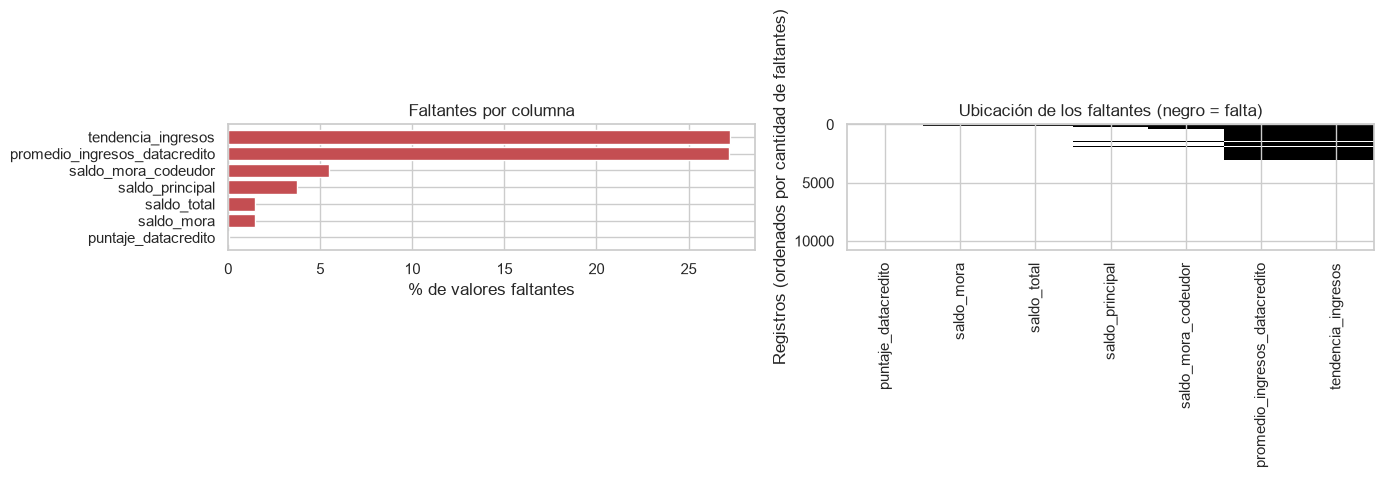

In [4]:
# Calcula el porcentaje de valores nulos por columna y conserva solo las columnas afectadas.
nulos_pct = (df.isna().mean() * 100).sort_values()
nulos_pct = nulos_pct[nulos_pct > 0]

# Crea una figura con un gráfico resumen y un mapa de distribución de faltantes.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Representa el porcentaje de valores faltantes de cada columna.
axes[0].barh(nulos_pct.index, nulos_pct.values, color="#c44e52")
axes[0].set_xlabel("% de valores faltantes")
axes[0].set_title("Faltantes por columna")

# Selecciona las columnas con nulos y ordena los registros por cantidad de faltantes.
con_nulos = df[nulos_pct.index]
orden = con_nulos.isna().sum(axis=1).sort_values(ascending=False).index

# Muestra la ubicación de los valores faltantes; el color negro indica un dato ausente.
axes[1].imshow(
    con_nulos.loc[orden].isna().values,
    aspect="auto",
    cmap="gray_r",
    interpolation="nearest"
)
axes[1].set_xticks(range(len(nulos_pct.index)))
axes[1].set_xticklabels(nulos_pct.index, rotation=90)
axes[1].set_ylabel("Registros (ordenados por cantidad de faltantes)")
axes[1].set_title("Ubicación de los faltantes (negro = falta)")

# Ajusta el diseño para evitar solapamientos y muestra la figura.
plt.tight_layout()
plt.show()

### Observaciones

El mapa ordena los registros por cantidad de faltantes, así que los más
incompletos quedan arriba.

**`promedio_ingresos_datacredito` y `tendencia_ingresos` faltan juntas.** El
bloque negro sólido muestra que cuando falta una, falta la otra. No son dos
faltantes independientes sino un único evento: el cliente no tiene información
en Datacrédito, y eso arrastra las dos variables de esa fuente.

Los faltantes de las columnas de saldo son pocos y caen en registros que ya son
incompletos. **Más del 70% del dataset no tiene ningún faltante.**

## Análisis de anomalías

In [5]:
# Inspecciona las columnas problemáticas detectadas en el resumen anterior.
print("--- tipo_laboral ---")
print(df["tipo_laboral"].value_counts())  # Cuenta la frecuencia de cada categoría.

print("\n--- tipo_credito ---")
print(df["tipo_credito"].value_counts())  # Cuenta la frecuencia de cada tipo de crédito.

print("\n--- saldo_mora_codeudor ---")
print(
    df["saldo_mora_codeudor"].value_counts(dropna=False)
)  # Incluye los valores nulos en el recuento.

print("\n--- saldo_mora (top 10) ---")
print(
    df["saldo_mora"].value_counts().head(10)
)  # Muestra los diez valores más frecuentes.

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

--- tipo_credito ---
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

--- saldo_mora_codeudor ---
saldo_mora_codeudor
0.0       10170
NaN         590
2145.0        1
30.0          1
470.0         1
Name: count, dtype: int64

--- saldo_mora (top 10) ---
saldo_mora
0.0       10552
30.0          2
132.0         1
366.0         1
5721.0        1
67.0          1
2145.0        1
238.0         1
63.0          1
4379.0        1
Name: count, dtype: int64


### Observaciones

- **`saldo_mora_codeudor`**: 99,97% de ceros. Con esa variabilidad casi no
  distingue entre clientes, aunque conviene evaluarlo antes de descartarla.
- **`saldo_mora`**: 99,5% de ceros. Y un saldo vencido se considera
  potencialmente posterior al incumplimiento: no es un antecedente disponible al
  momento de la solicitud. Se excluye por riesgo de fuga.
- **`tipo_credito`**: los tipos 4 y 9 concentran el 99%. El tipo 68 aparece una
  vez y rompe la secuencia de los demás. Una categoría con uno o dos casos
  puede quedar entera de un lado al particionar los datos.
- **`tipo_laboral`**: dicotómica, sin nulos y bien balanceada. La más limpia.

### Relación entre saldo_mora y saldo_mora_codeudor

In [6]:
# ¿Coinciden los casos con mora en titular y codeudor?
mora_titular = df["saldo_mora"] > 0                              # Crear booleano: ¿hay mora?
mora_codeudor = df["saldo_mora_codeudor"] > 0                    # Idem para codeudor

print("Titular con mora:", mora_titular.sum())                   # Contar True (mora)
print("Codeudor con mora:", mora_codeudor.sum())                 # Idem
print("Ambos con mora:", (mora_titular & mora_codeudor).sum())   # Contar registros con ambos en mora

# ¿Los nulos también coinciden?
print("\nNulos saldo_mora:", df["saldo_mora"].isna().sum())       # Contar NaN
print("Nulos saldo_mora_codeudor:", df["saldo_mora_codeudor"].isna().sum())
print("Nulos en ambas:", (df["saldo_mora"].isna() & df["saldo_mora_codeudor"].isna()).sum())

Titular con mora: 55
Codeudor con mora: 3
Ambos con mora: 3

Nulos saldo_mora: 156
Nulos saldo_mora_codeudor: 590
Nulos en ambas: 156


Los 3 casos de mora del codeudor son un subconjunto exacto de los 55 del
titular: no hay ni un registro donde el codeudor deba y el titular esté al día.
Tiene sentido, al codeudor se le reclama recién tras el incumplimiento. La
columna no agrega nada.

Aparte: 434 créditos tienen dato del titular pero no del codeudor —serían
créditos sin codeudor— y ahí el 0 no distingue entre "no debe" y "no hay".

### Relación entre saldo_total y saldo_principal

In [7]:
# Selecciona los registros que tienen ambos saldos informados.
saldos = df[["saldo_total", "saldo_principal"]].dropna()

# Compara cuántos registros presentan exactamente el mismo valor en ambos saldos.
iguales = (saldos["saldo_total"] == saldos["saldo_principal"]).sum()

print(f"Registros con ambos saldos: {len(saldos)}")
print(f"Valores idénticos: {iguales} ({iguales / len(saldos) * 100:.1f}%)")

# Mide la relación lineal entre el saldo total y el saldo principal.
print(f"Correlación: {saldos.corr().iloc[0, 1]:.4f}")

Registros con ambos saldos: 10358
Valores idénticos: 8658 (83.6%)
Correlación: 0.7347


### Observaciones

Coinciden en el 83,6% de los registros pero la correlación es 0,7347. La
diferencia está en el 16% restante, donde los saldos difieren mucho: la
correlación es sensible a los valores extremos.

La lectura es que la mayoría debe solo capital, y en el resto hay un componente
adicional que el dataset no permite identificar. No son redundantes, así que se
conservan las dos. La diferencia entre ambas queda anotada como posible
atributo derivado.

### Inspeccionar tendencia_ingresos

In [8]:
# Muestra las categorías más frecuentes de tendencia_ingresos,
# incluyendo los valores nulos para evaluar la calidad de la columna.
print(
    df["tendencia_ingresos"]
    .value_counts(dropna=False)
    .head(15)
)

print()

# Cuenta la cantidad de valores distintos, excluyendo los nulos.
print(
    "Total valores únicos:",
    df["tendencia_ingresos"].nunique()
)

tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
Name: count, dtype: int64

Total valores únicos: 46


### Observaciones

Además de las tres categorías esperadas y los 2.932 nulos, hay **58 registros
con números adentro**, algunos negativos y en la misma escala que los salarios.

**Hipótesis no verificable:** serían la variación de ingresos expresada como
monto en lugar de su categoría. El signo encaja, pero no hay forma de
confirmarlo.

**Por eso no se decide todavía.** Las alternativas para la preparación son
recodificar por signo (asumiendo la hipótesis), convertirlos a nulo, darles
categoría propia, o excluir la variable. Son el 0,5% del dataset, así que el
impacto de cualquiera es acotado.

## Duplicados

In [9]:
# Cuenta las filas completamente idénticas en todas sus columnas.
print("Duplicados exactos:", df.duplicated().sum())

Duplicados exactos: 0


## Estadísticos descriptivos

In [10]:
# Genera estadísticas descriptivas de las variables numéricas.
# La transposición facilita consultar cada variable por fila.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.0,5.411131e+00,2.338279e+00,4.00000,4.000000e+00,4.000000e+00,9.000000e+00,6.800000e+01
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01


### Detección de anomalías y valores extremos

In [11]:
# Comprueba valores constantes o fuera de rango en variables potencialmente problemáticas.
print(
    "puntaje == 95.227787:",
    (df["puntaje"].round(6) == 95.227787).sum()
)
print("puntaje negativo:", (df["puntaje"] < 0).sum())

print()

# Detecta salarios codificados como cero y valores de ingresos extremos.
print("salario == 0:", (df["salario_cliente"] == 0).sum())
print("salario > 50 millones:", (df["salario_cliente"] > 50_000_000).sum())

print()

# Identifica edades improbables y puntajes fuera de un rango válido.
print("edad > 90:", (df["edad_cliente"] > 90).sum())
print("puntaje_datacredito < 0:", (df["puntaje_datacredito"] < 0).sum())

puntaje == 95.227787: 9407
puntaje negativo: 135

salario == 0: 24
salario > 50 millones: 97

edad > 90: 150
puntaje_datacredito < 0: 1


Los conteos anteriores se visualizan mejor en un boxplot: la caja es el 50%
central de los datos y los puntos sueltos son los valores atípicos.

C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\377084777.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\377084777.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\377084777.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\377084777.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientati

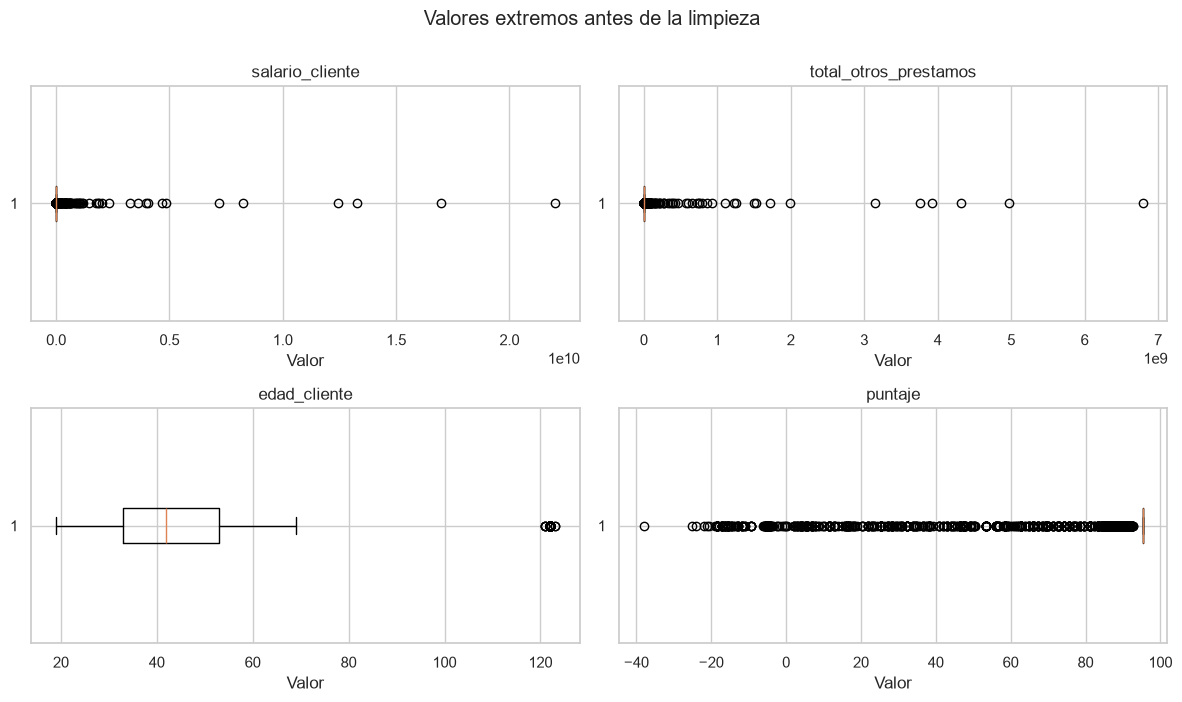

In [12]:
# Define las variables con posibles valores extremos.
extremos = ["salario_cliente", "total_otros_prestamos", "edad_cliente", "puntaje"]

# Crea una cuadrícula de cuatro gráficos.
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

# Genera un boxplot horizontal para cada variable.
for i, col in enumerate(extremos):
    # Elimina los valores nulos antes de graficar.
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")

# Ajusta el diseño y muestra los gráficos.
plt.suptitle("Valores extremos antes de la limpieza", y=1.00)
plt.tight_layout()
plt.show()

### Observaciones

**`salario_cliente` y `total_otros_prestamos`**: la caja se reduce a una línea
pegada al cero mientras los puntos llegan a 22.000 y 6.787 millones. Es la
imagen de sus skew de 43,7 y 38,5.

**`edad_cliente` muestra un grupo separado, no una cola.** La caja es normal
—mediana 42, bigotes hasta 69— y después hay un vacío total entre 69 y 120
años. Los 150 casos atípicos aparecen agrupados en 120-123. Ese salto refuerza
que es un error sistemático de carga, no edades reales dispersas.

**`puntaje`**: la caja es invisible porque el 87,4% de los valores es el mismo
número. Todo lo demás queda como atípico, incluidos los negativos hasta -38.

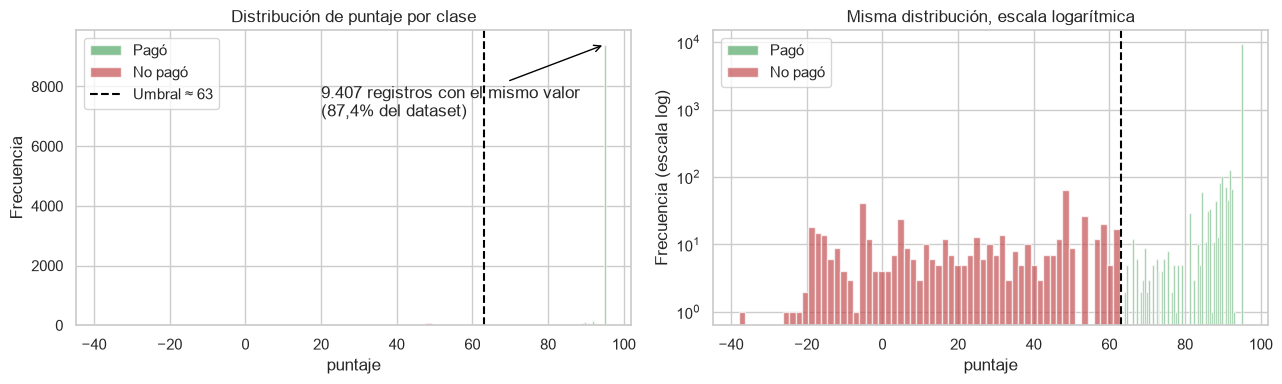

In [13]:
# Crea una figura con dos gráficos para comparar el puntaje por clase.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Genera histogramas superpuestos para los créditos pagados y no pagados.
for clase, color, etiqueta in [(1, "#55a868", "Pagó"), (0, "#c44e52", "No pagó")]:
    axes[0].hist(
        df.loc[df["Pago_atiempo"] == clase, "puntaje"],
        bins=60,
        alpha=0.7,
        color=color,
        label=etiqueta
    )

# Marca el umbral aproximado que separa las dos clases.
axes[0].axvline(63, color="black", linestyle="--", label="Umbral ≈ 63")
axes[0].set_xlabel("puntaje")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de puntaje por clase")
axes[0].legend()

# Anota la concentración de registros con el mismo valor de puntaje.
axes[0].annotate(
    "9.407 registros con el mismo valor\n(87,4% del dataset)",
    xy=(95, 9407),
    xytext=(20, 7000),
    arrowprops=dict(arrowstyle="->", color="black")
)

# Repite los histogramas en el segundo eje para usar una escala logarítmica.
for clase, color, etiqueta in [(1, "#55a868", "Pagó"), (0, "#c44e52", "No pagó")]:
    axes[1].hist(
        df.loc[df["Pago_atiempo"] == clase, "puntaje"],
        bins=60,
        alpha=0.7,
        color=color,
        label=etiqueta
    )

# Configura el segundo gráfico para resaltar frecuencias pequeñas.
axes[1].axvline(63, color="black", linestyle="--")
axes[1].set_yscale("log")
axes[1].set_xlabel("puntaje")
axes[1].set_ylabel("Frecuencia (escala log)")
axes[1].set_title("Misma distribución, escala logarítmica")
axes[1].legend()

# Ajusta el diseño y muestra la figura final.
plt.tight_layout()
plt.show()

### Observaciones sobre los estadísticos descriptivos

- **`puntaje`**: el 87,4% comparte el valor `95.227787`, que además es el
  máximo. Los percentiles 25, 50 y 75 coinciden ahí. Más 135 negativos,
  inválidos para un score. Se analiza aparte en la sección siguiente.
- **`salario_cliente`**: media de 17,2 M contra mediana de 3,0 M. 97 registros
  por encima de 50 millones —el máximo llega a 22.000 millones— y 24 en 0, que
  para un titular de crédito probablemente sea un faltante escrito como cero.
- **`total_otros_prestamos`**: misma asimetría, máximo de 6.787 M.
- **`edad_cliente`**: 150 registros por encima de 90 años, máximo de 123.
- **`puntaje_datacredito`**: un registro en -7, fuera de rango.
- **`Pago_atiempo`**: 95,25% de clase mayoritaria, solo 511 impagos. Un modelo
  que prediga "paga" para todos acierta el 95% sin detectar un solo caso de
  riesgo. Por eso la evaluación no puede apoyarse en accuracy.

### Relación de `puntaje` con la variable objetivo

La concentración de valores en `puntaje` motiva verificar si el valor constante
se asocia al resultado del crédito.

In [14]:
# Identifica los registros que tienen el valor constante de puntaje.
puntaje_constante = df["puntaje"].round(6) == 95.227787

# Compara la presencia del valor constante con el resultado del crédito.
print("Frecuencias:")
print(pd.crosstab(puntaje_constante, df["Pago_atiempo"]))

# Calcula el porcentaje de cada clase dentro de cada grupo de puntaje.
print("\nPorcentaje por fila:")
porcentajes = pd.crosstab(
    puntaje_constante,
    df["Pago_atiempo"],
    normalize="index"
) * 100
print(porcentajes.round(2))

# Resume la distribución del puntaje separando los créditos pagados
# de los que no fueron pagados a tiempo.
print("\nDistribución de puntaje por clase:")
distribucion = df.groupby("Pago_atiempo")["puntaje"].describe()
print(distribucion.round(2))

Frecuencias:
Pago_atiempo    0     1
puntaje                
False         511   845
True            0  9407

Porcentaje por fila:
Pago_atiempo      0       1
puntaje                    
False         37.68   62.32
True           0.00  100.00

Distribución de puntaje por clase:
                count   mean    std    min    25%    50%    75%    max
Pago_atiempo                                                          
0               511.0  23.09  26.07 -38.01  -3.59  25.42  47.61  62.67
1             10252.0  94.56   2.87  63.81  95.23  95.23  95.23  95.23


El gráfico lo confirma: a la izquierda del umbral solo hay impagos y a la
derecha solo pagos. Ninguna barra cruza la línea.

La escala logarítmica del panel derecho es necesaria porque los 9.407 registros
del valor constante aplastan visualmente al resto.

### Observaciones

**El valor constante separa perfectamente las clases.** Los 9.407 registros con
`95.227787` pagaron sin excepción. Los 511 impagos están todos entre los 1.356
con valor distinto, donde el incumplimiento sube al 37,68%.

**Y los rangos no se solapan:** el máximo entre los impagos es 62,67 y el
mínimo entre los que pagaron es 63,81. Un umbral en 63 clasifica correctamente
el 100% de los registros.

Una separación perfecta entre clases no es esperable en un predictor legítimo:
ninguna otra variable del dataset se aproxima siquiera a ese comportamiento.
Indica fuga de información: la variable o bien
deriva del resultado, o bien se calculó con posterioridad. No es posible
determinar cuál de las dos situaciones ocurre, pero cualquiera de ellas la
inhabilita como predictor: entrenar con ella daría métricas casi perfectas y
fallaría con clientes nuevos, porque ese puntaje no existe al momento de la
solicitud.

**Se excluye.** La conclusión es la opuesta a la primera impresión: el problema
no es la falta de información sino su exceso.

## Variable temporal

In [15]:
# Convierte la columna de fechas al formato datetime para poder analizarla.
fechas = pd.to_datetime(df["fecha_prestamo"])

# Muestra la primera y la última fecha registrada en el dataset.
print("Desde:", fechas.min())
print("Hasta:", fechas.max())

# Calcula la duración total del período analizado en días.
print("Rango:", (fechas.max() - fechas.min()).days, "días")

print()

# Agrupa las fechas por mes y cuenta la cantidad de créditos en cada período.
creditos_por_mes = fechas.dt.to_period("M").value_counts().sort_index()
print(creditos_por_mes)

Desde: 2024-11-26 09:17:04
Hasta: 2026-04-26 18:43:52
Rango: 516 días

fecha_prestamo
2024-11     186
2024-12    1216
2025-01    1917
2025-02    1094
2025-03    1115
2025-04    1102
2025-05    1083
2025-06     665
2025-07     644
2025-08     555
2025-09     361
2025-10     231
2025-11     166
2025-12     174
2026-01     127
2026-02      76
2026-03      40
2026-04      11
Freq: M, Name: count, dtype: int64


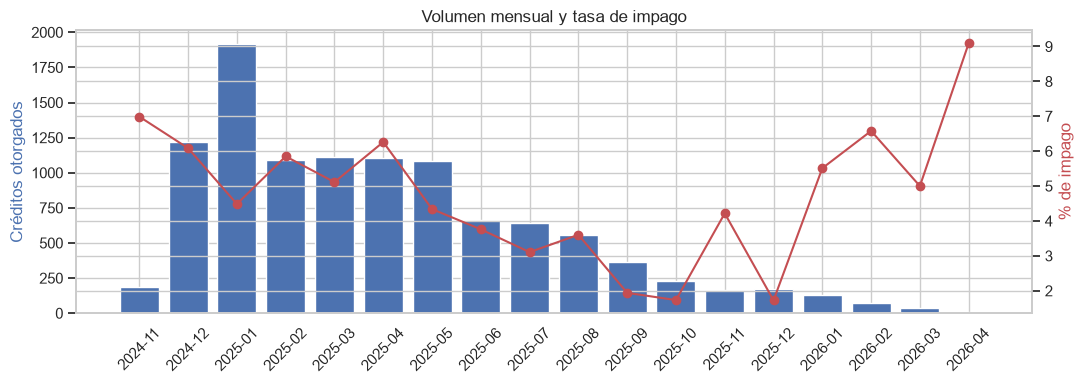

In [16]:
# Convierte las fechas y agrupa los créditos por mes.
fecha = pd.to_datetime(df["fecha_prestamo"])
por_mes = df.groupby(fecha.dt.to_period("M")).agg(
    # Cuenta la cantidad de créditos otorgados en cada mes.
    creditos=("Pago_atiempo", "size"),
    # Calcula el porcentaje mensual de créditos no pagados a tiempo.
    pct_impago=("Pago_atiempo", lambda x: (1 - x.mean()) * 100)
)

# Convierte los períodos mensuales a texto para usarlos en el eje X.
meses = por_mes.index.astype(str)

# Crea la figura y el primer eje para representar el volumen de créditos.
fig, ax1 = plt.subplots(figsize=(11, 4))

# Muestra la cantidad de créditos otorgados por mes mediante barras.
ax1.bar(meses, por_mes["creditos"], color="#4c72b0", label="Créditos")
ax1.set_ylabel("Créditos otorgados", color="#4c72b0")
ax1.tick_params(axis="x", rotation=45)

# Crea un segundo eje Y para representar el porcentaje de impago.
ax2 = ax1.twinx()

# Muestra la evolución mensual de la tasa de impago mediante una línea.
ax2.plot(
    meses,
    por_mes["pct_impago"],
    color="#c44e52",
    marker="o",
    label="% impago"
)
ax2.set_ylabel("% de impago", color="#c44e52")

# Ajusta el diseño y muestra el gráfico combinado.
plt.title("Volumen mensual y tasa de impago")
plt.tight_layout()
plt.show()

### Cruce mensual con otras variables

In [17]:
# Crea una copia del DataFrame para no modificar los datos originales.
df_temp = df.copy()

# Extrae el período mensual a partir de la fecha de cada crédito.
df_temp["mes"] = pd.to_datetime(
    df_temp["fecha_prestamo"]
).dt.to_period("M")

# Agrupa los registros por mes y calcula indicadores temporales.
resumen_mes = df_temp.groupby("mes").agg(
    # Cantidad total de créditos otorgados en cada mes.
    creditos=("Pago_atiempo", "size"),

    # Porcentaje de créditos que no se pagaron a tiempo.
    pct_impago=("Pago_atiempo", lambda x: (1 - x.mean()) * 100),

    # Porcentaje mensual de valores faltantes en los ingresos reportados.
    pct_nulos_ingresos=(
        "promedio_ingresos_datacredito",
        lambda x: x.isna().mean() * 100
    ),

    # Porcentaje mensual de valores faltantes en el saldo principal.
    pct_nulos_saldo=(
        "saldo_principal",
        lambda x: x.isna().mean() * 100
    ),

    # Salario mediano de los clientes de cada mes.
    salario_medio=("salario_cliente", "median"),

    # Edad promedio de los clientes de cada mes.
    edad_media=("edad_cliente", "mean")
).round(1)

# Muestra el resumen mensual de volumen, riesgo y calidad de los datos.
resumen_mes

,creditos,pct_impago,pct_nulos_ingresos,pct_nulos_saldo,salario_medio,edad_media
mes,,,,,,
2024-11,186,7.0,32.8,6.5,2500000.0,42.0
2024-12,1216,6.1,31.9,3.5,2800000.0,43.1
2025-01,1917,4.5,26.2,2.5,3000000.0,44.0
2025-02,1094,5.9,23.7,3.7,3000000.0,44.2
2025-03,1115,5.1,26.1,3.8,3100000.0,44.2
2025-04,1102,6.3,27.0,3.4,3100000.0,44.4
2025-05,1083,4.3,27.3,5.2,3500000.0,45.1
2025-06,665,3.8,26.2,5.6,3500000.0,45.0
2025-07,644,3.1,35.6,4.7,3000000.0,44.3


In [18]:
# Evalúa si los meses recientes concentran créditos de plazo más corto,
# lo que explicaría el descenso de volumen por maduración de la cartera.
plazo_mensual = df_temp.groupby("mes")["plazo_meses"].mean().round(1)
print(plazo_mensual.to_string())

mes
2024-11    11.5
2024-12    11.4
2025-01    10.8
2025-02    10.6
2025-03    10.4
2025-04    10.2
2025-05     9.5
2025-06     9.2
2025-07     9.4
2025-08     9.4
2025-09    10.2
2025-10    11.4
2025-11    11.7
2025-12    16.3
2026-01    16.5
2026-02    14.3
2026-03    14.7
2026-04     9.8
Freq: M


### Observaciones

El dataset abarca 516 días. El volumen cae de **1.917 créditos en enero de 2025
a 11 en abril de 2026**. Ninguna financiera pierde el 99% de su actividad en
línea recta, así que probablemente sea un efecto de cómo se armó el archivo.

Probamos dos explicaciones y ninguna encaja:

1. **Maduración.** Si los meses recientes trajeran solo créditos de plazo corto,
   el plazo promedio debería bajar. Sube: de 9,2 meses en junio de 2025 a 16,5
   en enero de 2026. No descarta del todo el efecto —comprobarlo requeriría la
   fecha de extracción, que no está— pero no lo respalda.
2. **Corte abrupto.** Daría actividad normal hasta cierto día y nada después.
   Los registros siguen apareciendo hasta el final, cada vez más espaciados.
   Descarta el corte, pero no una carga parcial o un ETL incompleto.

**La tasa de impago forma una U**: baja del 7,0% al 1,7% y después sube al 9,1%.
Esa subida coincide con los meses de menor volumen: los últimos puntos se
calculan sobre 76, 40 y 11 registros, y el 9,1% final es un único caso. La
bajada sí tiene respaldo y es compatible con que los créditos recientes hayan
tenido menos tiempo para caer en mora, aunque no se verificó.

El perfil del cliente se mantiene estable en todo el período, de modo que no se
observa evidencia de un cambio en la política de otorgamiento. No hay información para determinar la
causa del descenso. Queda anotado para definir la partición en el modelado.

## Patrón de los valores faltantes

In [19]:
# Crea una copia para añadir variables auxiliares sin modificar el DataFrame original.
df_temp = df.copy()

# Convierte la fecha del préstamo al formato datetime.
df_temp["fecha"] = pd.to_datetime(df_temp["fecha_prestamo"])

# Marca los registros que no tienen información de ingresos.
df_temp["sin_ingresos"] = (
    df_temp["promedio_ingresos_datacredito"].isna()
)

# Compara la fecha mediana de los registros con y sin información de ingresos.
fecha_con_ingresos = df_temp.loc[
    ~df_temp["sin_ingresos"], "fecha"
].median()

fecha_sin_ingresos = df_temp.loc[
    df_temp["sin_ingresos"], "fecha"
].median()

print("Con ingresos - fecha mediana:", fecha_con_ingresos)
print("Sin ingresos - fecha mediana:", fecha_sin_ingresos)

Con ingresos - fecha mediana: 2025-03-27 15:48:51
Sin ingresos - fecha mediana: 2025-03-28 12:08:57.500000


### Asociaciones de los datos faltantes

Los nulos no se distribuyen uniformemente. Ahora analizamos cómo se asocian con características del cliente y del riesgo de incumplimiento.

In [20]:
# Identifica los registros que no tienen información de ingresos.
df_temp["sin_ingresos"] = (
    df_temp["promedio_ingresos_datacredito"].isna()
)

# Calcula la proporción de valores faltantes según el tipo de empleo.
faltantes_por_empleo = (
    df_temp.groupby("tipo_laboral")["sin_ingresos"]
    .mean()
    .round(3)
)
print("Faltantes por tipo de empleo:")
print(faltantes_por_empleo)

print()

# Calcula la proporción de valores faltantes según el tipo de crédito.
faltantes_por_credito = (
    df_temp.groupby("tipo_credito")["sin_ingresos"]
    .mean()
    .round(3)
)
print("Faltantes por tipo de crédito:")
print(faltantes_por_credito)

print()

# Compara la tasa de impago entre clientes con y sin información de ingresos.
impago_con_ingresos = (
    1 - df_temp.loc[~df_temp["sin_ingresos"], "Pago_atiempo"].mean()
).round(4)

impago_sin_ingresos = (
    1 - df_temp.loc[df_temp["sin_ingresos"], "Pago_atiempo"].mean()
).round(4)

print("Impago con ingresos:", impago_con_ingresos)
print("Impago sin ingresos:", impago_sin_ingresos)

Faltantes por tipo de empleo:
tipo_laboral
Empleado         0.19
Independiente    0.41
Name: sin_ingresos, dtype: float64

Faltantes por tipo de crédito:
tipo_credito
4     0.252
6     0.190
7     0.500
9     0.329
10    0.250
68    0.000
Name: sin_ingresos, dtype: float64

Impago con ingresos: 0.0438
Impago sin ingresos: 0.0573


In [21]:
# Importa la prueba chi-cuadrado para evaluar la asociación entre variables categóricas.
from scipy.stats import chi2_contingency

# Construye una tabla de contingencia entre la ausencia de ingresos
# y el resultado del pago del crédito.
tabla = pd.crosstab(
    df["promedio_ingresos_datacredito"].isna(),
    df["Pago_atiempo"]
)

# Aplica la prueba chi-cuadrado de independencia.
chi2, p_valor, _, _ = chi2_contingency(tabla)

# Muestra la tabla observada y el p-valor de la prueba estadística.
print(tabla)
print(f"\np-valor: {p_valor:.4f}")

Pago_atiempo                     0     1
promedio_ingresos_datacredito           
False                          343  7490
True                           168  2762

p-valor: 0.0038


### Observaciones

**Sin concentración temporal.** La fecha mediana de los registros con dato y sin
dato difiere en un día sobre 516. El salto de nulos en los últimos meses —del
16,7% al 90,9%— es un espejismo del bajo volumen: ese 90,9% son 10 registros
sobre 11.

**Sí se asocia al tipo laboral.** El 41% de los independientes no tiene el dato
contra el 19% de los empleados. Una explicación posible —no verificable acá— es
que verificar ingresos de un cuentapropista es más difícil. Lo que queda
establecido es más acotado: la ausencia no se reparte de manera uniforme entre
los grupos observados.

**Y se asocia al impago:** 5,73% contra 4,38%. Como la diferencia parecía chica
la medimos con chi-cuadrado, y el p-valor de 0,0038 hace poco compatible la hipótesis de independencia. La
magnitud igual es moderada, así que queda establecida la asociación, no su peso
como predictor.

**Implicancia.** Al imputar hay que agregar un indicador binario que preserve
cuáles estaban vacíos. Si se rellena y se olvida, la señal se pierde.

## Limitaciones del dataset

No hay documentación de las variables, así que la interpretación de
`tipo_credito`, `huella_consulta` o `puntaje` se apoya en convenciones del
dominio y en lo que muestran los datos.

Pesa más sobre la interpretación que sobre el modelado: al algoritmo le da igual
qué significa el código 9, lo usa como agrupador. Pero traducir un hallazgo a
una decisión de negocio sí requiere saberlo, y esa traducción puede hacerla el
área propietaria del dato.

Quedan abiertos el momento en que se calcula `puntaje` —la separación perfecta
de clases alcanza igual para excluirla— y el origen de los 58 valores numéricos
de `tendencia_ingresos`.

## Limpieza de datos

Con los problemas ya documentados, se aplican las correcciones. El orden va de
lo menos invasivo a lo más: primero tipos y valores, y las eliminaciones al
final, para conservar las columnas disponibles por si hacen falta en alguna
verificación intermedia.

Se trabaja sobre una copia (`df_limpio`) para poder comparar contra el original.

In [22]:
# Crea una copia del DataFrame original para aplicar la limpieza
# sin modificar los datos de referencia.
df_limpio = df.copy()

# Confirma el tamaño del dataset utilizado para la limpieza.
print(
    f"Copia creada: {df_limpio.shape[0]} filas, "
    f"{df_limpio.shape[1]} columnas"
)

Copia creada: 10763 filas, 23 columnas


### Conversión de tipos

`fecha_prestamo` está almacenada como texto. Sin convertirla no se puede
ordenar cronológicamente ni derivar el mes o el año.

In [23]:
# Convierte la fecha del préstamo al formato datetime
# para permitir operaciones y análisis temporales.
df_limpio["fecha_prestamo"] = pd.to_datetime(
    df_limpio["fecha_prestamo"]
)

# Verifica el tipo de dato y el rango temporal disponible.
print("Tipo:", df_limpio["fecha_prestamo"].dtype)
print(
    "Rango:",
    df_limpio["fecha_prestamo"].min(),
    "→",
    df_limpio["fecha_prestamo"].max()
)

Tipo: datetime64[us]
Rango: 2024-11-26 09:17:04 → 2026-04-26 18:43:52


### Unificación de nulos

24 registros tienen `salario_cliente` en 0. Un titular de crédito con ingreso
declarado cero es inconsistente: lo más probable es que sea un dato faltante
representado como cero.

Se convierten a `NaN` para que queden registrados como lo que son. La decisión
de imputarlos o no se toma en la etapa de preparación, junto con el resto de
los faltantes.

In [24]:
# Cuenta los valores nulos existentes antes de la corrección.
antes = df_limpio["salario_cliente"].isna().sum()

# Convierte los salarios iguales a cero en valores faltantes,
# ya que no representan un ingreso válido para este análisis.
df_limpio.loc[
    df_limpio["salario_cliente"] == 0,
    "salario_cliente"
] = pd.NA

# Cuenta los valores nulos después de reemplazar los ceros.
despues = df_limpio["salario_cliente"].isna().sum()

# Compara la cantidad de nulos antes y después del tratamiento.
print(f"Nulos en salario_cliente: {antes} → {despues}")

Nulos en salario_cliente: 0 → 24


### Corrección de valores fuera de rango

Se convierten a nulo en vez de eliminar la fila: el resto del registro es
válido.

- **`puntaje_datacredito`**: un registro en -7, fuera del rango del score.
- **`edad_cliente`**: 150 registros por encima de 90 años. Como titular de
  crédito activo es muy improbable, y 150 casos son demasiados para ser reales.
  El límite inferior no requiere corrección: la edad mínima observada es 19.

Dos casos se conservan:

- **`salario_cliente`**: los 97 registros sobre 50 millones son atípicos, pero
  un ingreso alto no es imposible y no hay umbral claro entre lo raro y lo
  inválido. Se tratan como outliers en la preparación, con transformación de
  escala.
- **`tipo_credito` = 68**: un único registro. Se conserva por ahora y se
  incorpora al tratamiento de categorías minoritarias en la preparación.

In [25]:
# Guarda el conteo de nulos previo para reportar el cambio de forma dinámica.
antes = df_limpio[["puntaje_datacredito", "edad_cliente"]].isna().sum()

# Reemplaza los puntajes negativos por NaN porque están fuera del rango válido.
df_limpio.loc[df_limpio["puntaje_datacredito"] < 0, "puntaje_datacredito"] = np.nan

# Reemplaza las edades superiores a 90 años por NaN: son implausibles
# para un titular de crédito activo.
df_limpio.loc[df_limpio["edad_cliente"] > 90, "edad_cliente"] = np.nan

# El límite inferior de edad (18 años) no requiere corrección: el mínimo
# observado es 19.
print("Edad mínima:", df_limpio["edad_cliente"].min())

despues = df_limpio[["puntaje_datacredito", "edad_cliente"]].isna().sum()
print("\nNulos antes → después:")
for col in antes.index:
    print(f"  {col:22} {antes[col]:4} → {despues[col]:4}")

Edad mínima: 19.0

Nulos antes → después:
  puntaje_datacredito       6 →    7
  edad_cliente              0 →  150


### Tratamiento de tendencia_ingresos

Antes de decidir qué hacer con los 58 registros numéricos, se verifica si
presentan algún comportamiento particular respecto de la variable objetivo.

In [26]:
# Convierte temporalmente tendencia_ingresos a numérico.
# Los valores numéricos representan registros anómalos.
anomalos = pd.to_numeric(
    df["tendencia_ingresos"],
    errors="coerce"
).notna()

# Cuenta cuántos registros contienen valores numéricos inesperados.
print(f"Registros anómalos: {anomalos.sum()}")

# Calcula la tasa de impago entre los registros anómalos.
impago_anomalos = (
    1 - df.loc[anomalos, "Pago_atiempo"].mean()
) * 100

# Calcula la tasa de impago entre los registros restantes.
impago_resto = (
    1 - df.loc[~anomalos, "Pago_atiempo"].mean()
) * 100

print(f"Impago en anómalos: {impago_anomalos:.2f}%")
print(f"Impago en el resto:  {impago_resto:.2f}%")

Registros anómalos: 58
Impago en anómalos: 0.00%
Impago en el resto:  4.77%


In [27]:
# Identifica los registros con valores numéricos anómalos en tendencia_ingresos.
anomalos = pd.to_numeric(
    df["tendencia_ingresos"],
    errors="coerce"
).notna()

# Identifica los registros que tienen el valor constante de puntaje.
puntaje_constante = (
    df["puntaje"].round(6) == 95.227787
)

# Comprueba cuántos registros anómalos pertenecen al grupo
# con puntaje constante.
print(
    "Anómalos con puntaje constante:",
    (anomalos & puntaje_constante).sum(),
    "de 58"
)

print()

# Compara la fecha mediana de los registros anómalos
# con la del resto del dataset.
fecha_anomalos = pd.to_datetime(
    df.loc[anomalos, "fecha_prestamo"]
).median()

fecha_resto = pd.to_datetime(
    df.loc[~anomalos, "fecha_prestamo"]
).median()

print("Fecha mediana anómalos:", fecha_anomalos)
print("Fecha mediana resto:   ", fecha_resto)

Anómalos con puntaje constante: 54 de 58

Fecha mediana anómalos: 2025-03-18 01:19:49
Fecha mediana resto:    2025-03-27 17:07:26


### Observaciones

La tasa de impago de los 58 anómalos es 0% contra 4,77% del resto, pero el dato
no concluye nada: 54 de esos 58 tienen `puntaje` constante, y ese grupo paga en
su totalidad. El resultado refleja su composición, no una característica propia.
Tampoco hay concentración temporal.

**Decisión: categoría propia.** Se agrupan bajo `valor_anomalo`. Recodificar por
signo asumiría la hipótesis no verificable; convertirlos a nulo los disolvería
entre los 2.932 faltantes y sería irreversible. Con categoría propia quedan
identificables y disponibles para recodificar si más adelante se confirma su
origen.

In [28]:
# Identifica los valores de tendencia_ingresos que pueden convertirse a número.
# Estos valores corresponden a los registros anómalos detectados.
es_numerico = pd.to_numeric(
    df_limpio["tendencia_ingresos"],
    errors="coerce"
).notna()

# Reemplaza los valores numéricos por una categoría explícita,
# sin asumir qué significan originalmente.
df_limpio.loc[
    es_numerico,
    "tendencia_ingresos"
] = "valor_anomalo"

# Verifica la distribución final de categorías, incluidos los valores nulos.
print(
    df_limpio["tendencia_ingresos"]
    .value_counts(dropna=False)
)

tendencia_ingresos
Creciente        5294
NaN              2932
Decreciente      1291
Estable          1188
valor_anomalo      58
Name: count, dtype: int64


### Eliminación de variables

Se eliminan tres columnas, dos de ellas por fuga: contienen información que no
estaría disponible al evaluar una solicitud nueva.

- **`puntaje`** — separa las clases de forma perfecta. Solo puede haberse
  determinado conociendo el resultado.
- **`saldo_mora`** — un saldo vencido se considera potencialmente posterior al
  incumplimiento, de modo que no estaría disponible al momento de la solicitud.
- **`saldo_mora_codeudor`** — sus 3 casos con mora son un subconjunto de los 55
  de `saldo_mora`, así que arrastra el mismo problema, y con 99,97% de ceros no
  aporta variabilidad propia.

Se conserva `fecha_prestamo`: aunque funciona como identificador, permite
derivar atributos temporales.

In [29]:
# Define las variables que se eliminarán por fuga de información
# o por aportar poca variabilidad útil al modelo.
a_eliminar = [
    "puntaje",
    "saldo_mora",
    "saldo_mora_codeudor"
]

# Elimina las columnas seleccionadas del DataFrame limpio.
df_limpio = df_limpio.drop(columns=a_eliminar)

# Verifica cuántas columnas se eliminaron y el tamaño final del dataset.
print(f"Columnas eliminadas: {len(a_eliminar)}")
print(
    f"Dataset: {df_limpio.shape[1]} columnas "
    f"(antes {df.shape[1]})"
)

Columnas eliminadas: 3
Dataset: 20 columnas (antes 23)


### Verificación final

Estado del dataset tras la limpieza, comparado con el original.

In [30]:
# Compara la cantidad de filas antes y después de la limpieza.
print(f"Filas:    {df.shape[0]} → {df_limpio.shape[0]}")

# Compara la cantidad de columnas antes y después de la limpieza.
print(f"Columnas: {df.shape[1]} → {df_limpio.shape[1]}")

print()

# Muestra únicamente las columnas que aún contienen valores nulos,
# ordenadas desde la mayor hasta la menor cantidad.
print("Nulos por columna:")
nulos_restantes = (
    df_limpio.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
)
print(nulos_restantes)

print()

# Resume cuántas columnas hay de cada tipo de dato.
print("Tipos de dato:")
print(df_limpio.dtypes.value_counts())

Filas:    10763 → 10763
Columnas: 23 → 20

Nulos por columna:
tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_principal                   405
saldo_total                       156
edad_cliente                      150
salario_cliente                    24
puntaje_datacredito                 7
dtype: int64

Tipos de dato:
int64             10
float64            7
str                2
datetime64[us]     1
Name: count, dtype: int64


## Análisis exploratorio

### Variable objetivo

`Pago_atiempo` es binaria: 1 es que el crédito se pagó a tiempo, 0 que no. Es
lo que el modelo tiene que predecir.

              cantidad  porcentaje
Pago_atiempo                      
0                  511        4.75
1                10252       95.25


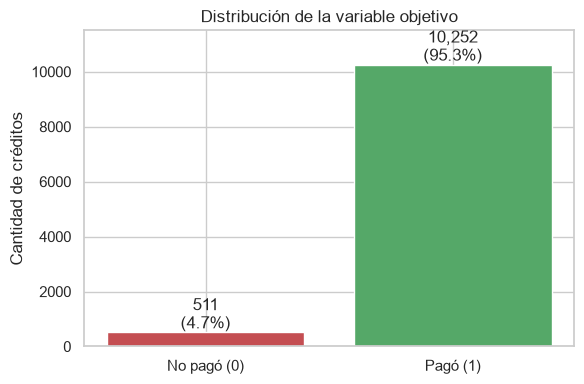

In [31]:
# Calcula la cantidad de registros de cada clase de la variable objetivo.
conteo = (
    df_limpio["Pago_atiempo"]
    .value_counts()
    .sort_index()
)

# Calcula el porcentaje que representa cada clase en el dataset.
pct = (
    df_limpio["Pago_atiempo"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Muestra el conteo y el porcentaje de cada clase.
print(
    pd.DataFrame({
        "cantidad": conteo,
        "porcentaje": pct.round(2)
    })
)

# Crea la figura para representar la distribución de la variable objetivo.
fig, ax = plt.subplots(figsize=(6, 4))

# Dibuja una barra para cada clase:
# 0 corresponde a créditos no pagados y 1 a créditos pagados.
ax.bar(
    ["No pagó (0)", "Pagó (1)"],
    conteo.values,
    color=["#c44e52", "#55a868"]
)

# Añade etiquetas con la cantidad y el porcentaje sobre cada barra.
for i, v in enumerate(conteo.values):
    ax.text(
        i,
        v + 150,
        f"{v:,}\n({pct.values[i]:.1f}%)",
        ha="center"
    )

# Configura el título, el eje Y y el límite superior del gráfico.
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Cantidad de créditos")
ax.set_ylim(0, 11500)

# Ajusta el diseño y muestra el gráfico.
plt.tight_layout()
plt.show()

### Observaciones

**10.252 créditos se pagaron a tiempo (95,25%) y 511 no (4,75%)**: veinte
pagados por cada impago. Eso condiciona dos cosas:

- **La métrica.** Un modelo que prediga "paga" para todos acierta el 95,25% sin
  detectar un solo cliente riesgoso. Cualquier accuracy cercana a ese número
  significa que no aprendió nada. Hay que evaluar con recall y F1 sobre la clase
  minoritaria, y con ROC-AUC.
- **El entrenamiento.** Con 511 impagos hay poca evidencia del patrón. Habrá que
  probar balanceo o ajuste de pesos.

### Análisis univariable — variables numéricas

Se analiza cada variable por separado. `tipo_credito` y `Pago_atiempo` figuran
como enteras pero son categóricas, así que quedan fuera.

**Skew** indica hacia qué lado se corre la distribución: cerca de 0 es
simétrica, positivo significa cola a la derecha —unos pocos valores muy altos
que estiran el promedio—. **Kurtosis** indica cuántos valores extremos hay lejos
del centro. Los dos responden qué tipo de distribución tiene cada variable.

In [32]:
# Define las variables numéricas que se analizarán.
numericas = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_total",
    "saldo_principal", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal",
    "promedio_ingresos_datacredito"
]

# Calcula estadísticas descriptivas para cada variable numérica.
# La transposición coloca cada variable en una fila.
resumen_num = df_limpio[numericas].describe().T

# Añade la asimetría de cada distribución.
resumen_num["skew"] = df_limpio[numericas].skew()

# Añade la curtosis para identificar distribuciones con valores extremos.
resumen_num["kurtosis"] = df_limpio[numericas].kurtosis()

# Redondea los resultados para facilitar su lectura.
resumen_num.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
capital_prestado,10763.0,2434315.00,1.909643e+06,360000.0,1224831.0,1921920.0,3084840.00,4.144415e+07,3.72,35.32
plazo_meses,10763.0,10.58,6.630000e+00,2.0,6.0,10.0,12.00,9.000000e+01,2.46,7.78
edad_cliente,10613.0,42.85,1.195000e+01,19.0,33.0,42.0,52.00,6.900000e+01,0.27,-0.86
salario_cliente,10739.0,17254907.51,3.558728e+08,1000.0,2000000.0,3000000.0,4900000.00,2.200000e+10,43.73,2206.30
total_otros_prestamos,10763.0,6238869.65,1.184183e+08,0.0,500000.0,1000000.0,2000000.00,6.787675e+09,38.46,1719.28
cuota_pactada,10763.0,243617.41,2.104937e+05,23944.0,121041.5,182863.0,287833.50,3.816752e+06,3.79,26.65
puntaje_datacredito,10756.0,780.86,1.046100e+02,0.0,757.0,791.0,825.00,9.990000e+02,-5.65,39.60
cant_creditosvigentes,10763.0,5.73,3.980000e+00,0.0,3.0,5.0,8.00,6.200000e+01,1.80,8.62
huella_consulta,10763.0,4.23,3.060000e+00,0.0,2.0,4.0,6.00,2.900000e+01,1.49,4.00
saldo_total,10607.0,45937.41,1.062698e+05,0.0,2898.0,16178.0,52982.00,5.116066e+06,20.20,789.17


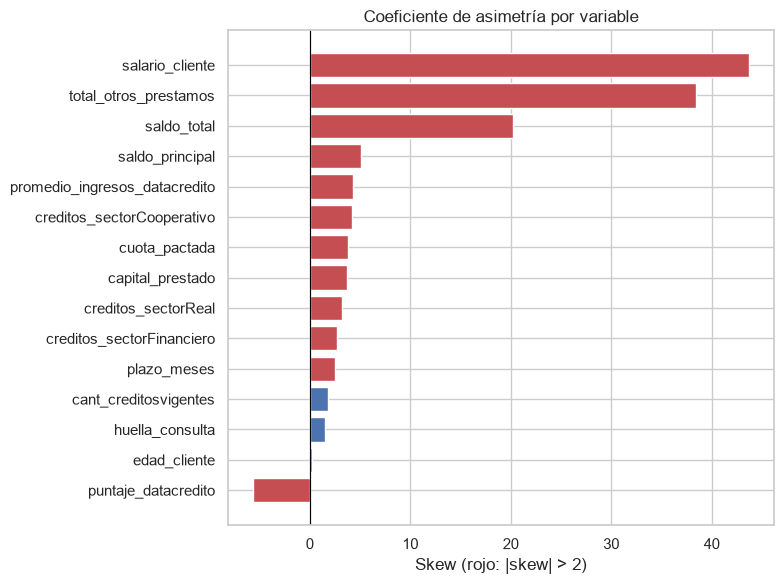

In [33]:
# Calcula la asimetría de cada variable y las ordena de menor a mayor.
skews = df_limpio[numericas].skew().sort_values()

# Crea la figura donde se visualizarán los coeficientes.
fig, ax = plt.subplots(figsize=(8, 6))

# Resalta en rojo las variables con asimetría fuerte, cuyo valor absoluto
# es mayor que 2; las demás se muestran en azul.
colores = [
    "#c44e52" if abs(s) > 2 else "#4c72b0"
    for s in skews.values
]

# Representa los coeficientes mediante barras horizontales.
ax.barh(skews.index, skews.values, color=colores)

# Añade una línea de referencia en cero para distinguir el sentido del sesgo.
ax.axvline(0, color="black", linewidth=0.8)

# Configura el título y la etiqueta del eje horizontal.
ax.set_title("Coeficiente de asimetría por variable")
ax.set_xlabel("Skew (rojo: |skew| > 2)")

# Ajusta el diseño y muestra el gráfico.
plt.tight_layout()
plt.show()

### Observaciones

**Once de las quince tienen sesgo fuerte** (|skew| > 2, las rojas). Tres están
en otra escala: `salario_cliente` (43,7), `total_otros_prestamos` (38,5) y
`saldo_total` (20,2); las otras ocho van de 2 a 5.

Solo cuatro quedan debajo del umbral: `cant_creditosvigentes` (1,8) y
`huella_consulta` (1,5) con sesgo moderado, `edad_cliente` (0,27) —la única
aproximadamente simétrica— y `puntaje_datacredito` (-0,99), la única con cola
hacia la izquierda, coherente con un score donde la mayoría puntúa alto.

**Ninguna variable de monto es gaussiana**: predomina la forma logarítmica,
característica de las variables de dinero.

In [34]:
# Filtra los salarios inferiores a 100.000 y cuenta la frecuencia de cada valor.
salarios_bajos = (
    df_limpio.loc[
        df_limpio["salario_cliente"] < 100_000,
        "salario_cliente"
    ]
    .value_counts()
    .head(10)
)

# Muestra los diez valores más frecuentes dentro de los salarios bajos.
print(salarios_bajos)

salario_cliente
30285.0    3
1000.0     1
31809.0    1
33334.0    1
66667.0    1
Name: count, dtype: int64


In [35]:
# Cuenta los salarios que aún están por debajo de 100.000
# después del proceso de limpieza.
print(
    "Salarios menores a 100.000:",
    (df_limpio["salario_cliente"] < 100_000).sum()
)

# Cuenta los puntajes de Datacrédito iguales a cero,
# que se consideran valores faltantes codificados incorrectamente.
print(
    "puntaje_datacredito == 0:",
    (df_limpio["puntaje_datacredito"] == 0).sum()
)

Salarios menores a 100.000: 7
puntaje_datacredito == 0: 145


### Corrección adicional detectada en el análisis univariable

El resumen dejó a la vista dos mínimos inválidos:

- **`salario_cliente`**: 7 registros bajo 100.000, el menor de 1.000. Ningún
  ingreso de ese orden alcanza para un crédito de varios millones. El umbral de
  100.000 incluye también los 24 ceros ya corregidos, de modo que la regla
  final para producción es una sola: rechazar todo salario menor a 100.000.
- **`puntaje_datacredito`**: 145 registros en 0. El score no arranca en cero,
  así que ese valor es ausencia de historial, no un puntaje bajo. Tras la
  corrección el mínimo queda en 7, todavía por debajo del rango habitual del
  score; se deja constancia sin corregir cada caso aislado.

Los dos repiten lo de los 24 salarios en 0. La interpretación más plausible
—no verificable sin documentación— es que **el dataset use el cero como
sustituto de dato faltante**, que es justo lo que la consigna pide unificar.

In [36]:
# Guarda el conteo previo para reportar el cambio de forma dinámica.
antes = df_limpio[["salario_cliente", "puntaje_datacredito"]].isna().sum()

# Salarios menores a 100.000: ingresos incompatibles con el crédito otorgado.
# El umbral incluye también los 24 ceros ya tratados.
df_limpio.loc[df_limpio["salario_cliente"] < 100_000, "salario_cliente"] = np.nan

# Puntajes en 0: el score no arranca en cero, representan ausencia de historial.
df_limpio.loc[df_limpio["puntaje_datacredito"] == 0, "puntaje_datacredito"] = np.nan

despues = df_limpio[["salario_cliente", "puntaje_datacredito"]].isna().sum()
print("Nulos antes → después:")
for col in antes.index:
    print(f"  {col:22} {antes[col]:4} → {despues[col]:4}")

Nulos antes → después:
  salario_cliente          24 →   31
  puntaje_datacredito       7 →  152


In [37]:
# Selecciona las dos variables corregidas para comparar sus distribuciones.
variables_corregidas = [
    "salario_cliente",
    "puntaje_datacredito"
]

# Calcula el valor mínimo, la asimetría y la curtosis de cada variable.
comparacion = pd.DataFrame({
    "min": df_limpio[variables_corregidas].min(),
    "skew": df_limpio[variables_corregidas].skew(),
    "kurtosis": df_limpio[variables_corregidas].kurtosis()
})

# Redondea los resultados para facilitar su lectura.
print(comparacion.round(2))

                          min   skew  kurtosis
salario_cliente      243798.0  43.71   2204.86
puntaje_datacredito       7.0  -0.99      9.98


### Distribución de las variables de monto

Cinco variables en pesos, todas con sesgo positivo fuerte. Se grafica cada una
en escala original y logarítmica: el logaritmo comprime la escala y acerca los
valores grandes al resto, así que sirve para ver si la distribución se endereza.

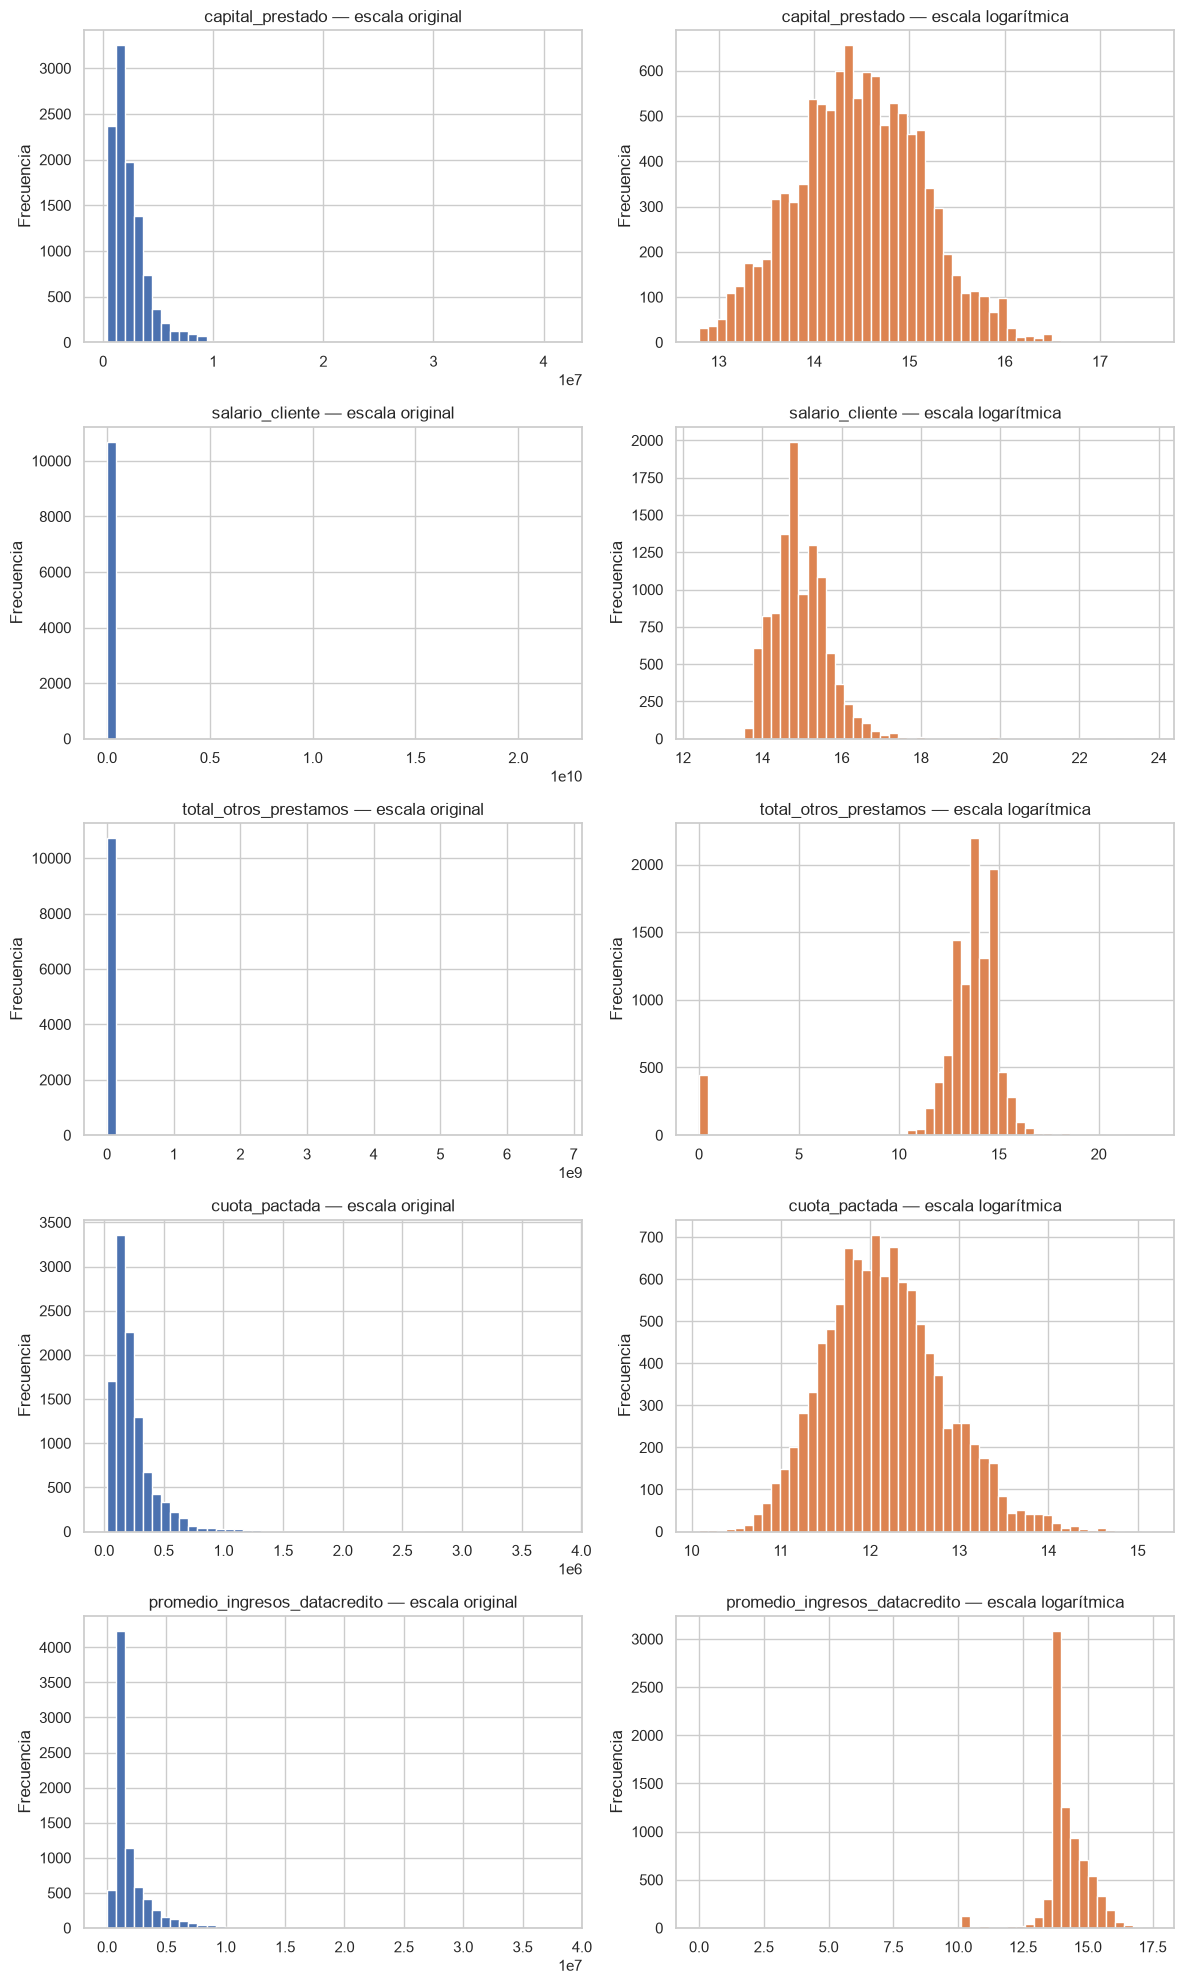

                               skew_original  skew_log
capital_prestado                        3.72      0.11
salario_cliente                        43.71      2.78
total_otros_prestamos                  38.46     -3.61
cuota_pactada                           3.79      0.40
promedio_ingresos_datacredito           4.28     -3.49


In [38]:
# Define las variables monetarias que se analizarán.
montos = [
    "capital_prestado",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada",
    "promedio_ingresos_datacredito"
]

# Crea dos gráficos por variable: escala original y escala logarítmica.
fig, axes = plt.subplots(
    len(montos),
    2,
    figsize=(12, 4 * len(montos))
)

# Genera los histogramas para cada variable monetaria.
for i, col in enumerate(montos):
    # Excluye los valores faltantes antes de realizar las transformaciones.
    datos = df_limpio[col].dropna()

    # Muestra la distribución en su escala original.
    axes[i, 0].hist(
        datos,
        bins=50,
        color="#4c72b0",
        edgecolor="white"
    )
    axes[i, 0].set_title(f"{col} — escala original")
    axes[i, 0].set_ylabel("Frecuencia")

    # Aplica log(1+x), que permite trabajar con valores iguales a cero.
    axes[i, 1].hist(
        np.log1p(datos),
        bins=50,
        color="#dd8452",
        edgecolor="white"
    )
    axes[i, 1].set_title(f"{col} — escala logarítmica")
    axes[i, 1].set_ylabel("Frecuencia")

# Ajusta la distribución de los gráficos y muestra la figura.
plt.tight_layout()
plt.show()

# Compara numéricamente la asimetría antes y después de aplicar el logaritmo.
efecto = pd.DataFrame({
    "skew_original": df_limpio[montos].skew(),
    "skew_log": df_limpio[montos].apply(
        lambda s: np.log1p(s.dropna()).skew()
    )
}).round(2)

print(efecto)

### Observaciones

**El logaritmo funciona en la mayoría de los casos.** `capital_prestado` y
`cuota_pactada` pasan de una barra pegada a la izquierda a una campana casi
perfecta.

**`salario_cliente` mejora pero le queda cola:** todavía se ven valores sueltos
entre 18 y 24, separados del cuerpo. Son los registros sobre 50 millones — el
logaritmo los acerca pero no los integra.

**Dos variables tienen un grupo separado en cero.** En escala logarítmica,
`total_otros_prestamos` y `promedio_ingresos_datacredito` muestran una barra
aislada sin nada que la conecte con el resto. Son clientes sin otros préstamos y
sin ingresos reportados: no es un valor bajo, es otra cosa.

| Variable | Skew original | Skew log |
|---|---|---|
| `capital_prestado` | 3,72 | 0,11 |
| `cuota_pactada` | 3,79 | 0,40 |
| `salario_cliente` | 43,71 | 2,78 |
| `total_otros_prestamos` | 38,46 | -3,61 |
| `promedio_ingresos_datacredito` | 4,28 | -3,49 |

Las dos últimas cambian de signo. No es que el logaritmo corrigiera de más: al
comprimirse el cuerpo, el grupo de ceros queda solo del lado izquierdo y **pasa
a ser la cola**. Ahí el problema no es de escala sino que hay dos poblaciones
distintas en la misma columna.

### Distribución de los saldos

`saldo_total` y `saldo_principal` registran la deuda que el cliente ya tiene en
otras obligaciones. Se agrega el **boxplot**, que muestra la mediana, el 50%
central de los datos (la caja) y los valores atípicos (los puntos sueltos).

C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\1652134073.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\1652134073.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)


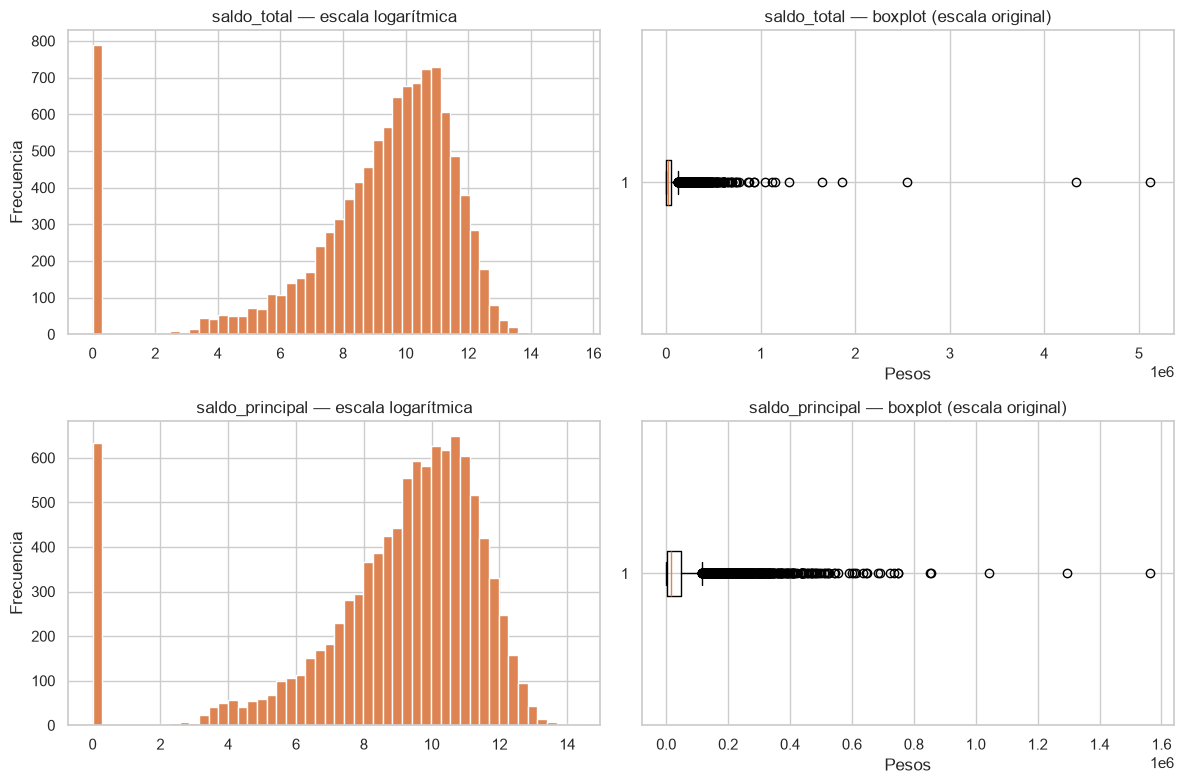

Registros en cero:
  saldo_total: 789 (7.4%)
  saldo_principal: 633 (6.1%)


In [39]:
# Define los saldos que se analizarán conjuntamente.
saldos = ["saldo_total", "saldo_principal"]

# Crea dos gráficos por saldo: histograma logarítmico y boxplot original.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Genera los gráficos para cada variable de saldo.
for i, col in enumerate(saldos):
    # Excluye los valores faltantes antes de graficar.
    datos = df_limpio[col].dropna()

    # Representa la distribución en escala logarítmica.
    axes[i, 0].hist(
        np.log1p(datos),
        bins=50,
        color="#dd8452",
        edgecolor="white"
    )
    axes[i, 0].set_title(f"{col} — escala logarítmica")
    axes[i, 0].set_ylabel("Frecuencia")

    # Usa un boxplot para observar mediana, cuartiles y valores extremos.
    axes[i, 1].boxplot(datos, vert=False)
    axes[i, 1].set_title(f"{col} — boxplot (escala original)")
    axes[i, 1].set_xlabel("Pesos")

# Ajusta el diseño y muestra los gráficos.
plt.tight_layout()
plt.show()

# Cuenta y calcula el porcentaje de registros con saldo igual a cero.
print("Registros en cero:")
for col in saldos:
    ceros = (df_limpio[col] == 0).sum()
    total_validos = df_limpio[col].notna().sum()
    porcentaje_ceros = ceros / total_validos * 100

    print(
        f"  {col}: {ceros} "
        f"({porcentaje_ceros:.1f}%)"
    )

### Observaciones

Los dos repiten la estructura de `total_otros_prestamos`: **una barra aislada en
cero** separada del cuerpo, que en escala logarítmica queda como una campana
centrada entre 10 y 11. Esos registros son clientes sin deuda vigente
reportada, condición distinta a tener un saldo bajo.

Los boxplots muestran el sesgo: la caja apenas se distingue y hay una nube de
puntos hasta 5,1 millones en `saldo_total` y 1,6 en `saldo_principal`.

**Implicancia**: ya van cuatro variables con la misma estructura. Es un patrón
del dataset, no una casualidad, y todas piden el mismo tratamiento: logaritmo
para el cuerpo más un indicador binario que marque la ausencia.

### Distribución de las variables de conteo

Cinco variables que cuentan cosas: créditos vigentes, consultas al historial y
créditos por sector. Son números enteros con un rango chico (de 0 a 62 en el
caso más amplio), así que se grafican en escala original —no hace falta
logaritmo— y con una barra por cada valor posible, para que se lea cuántos
clientes tienen exactamente cada cantidad.

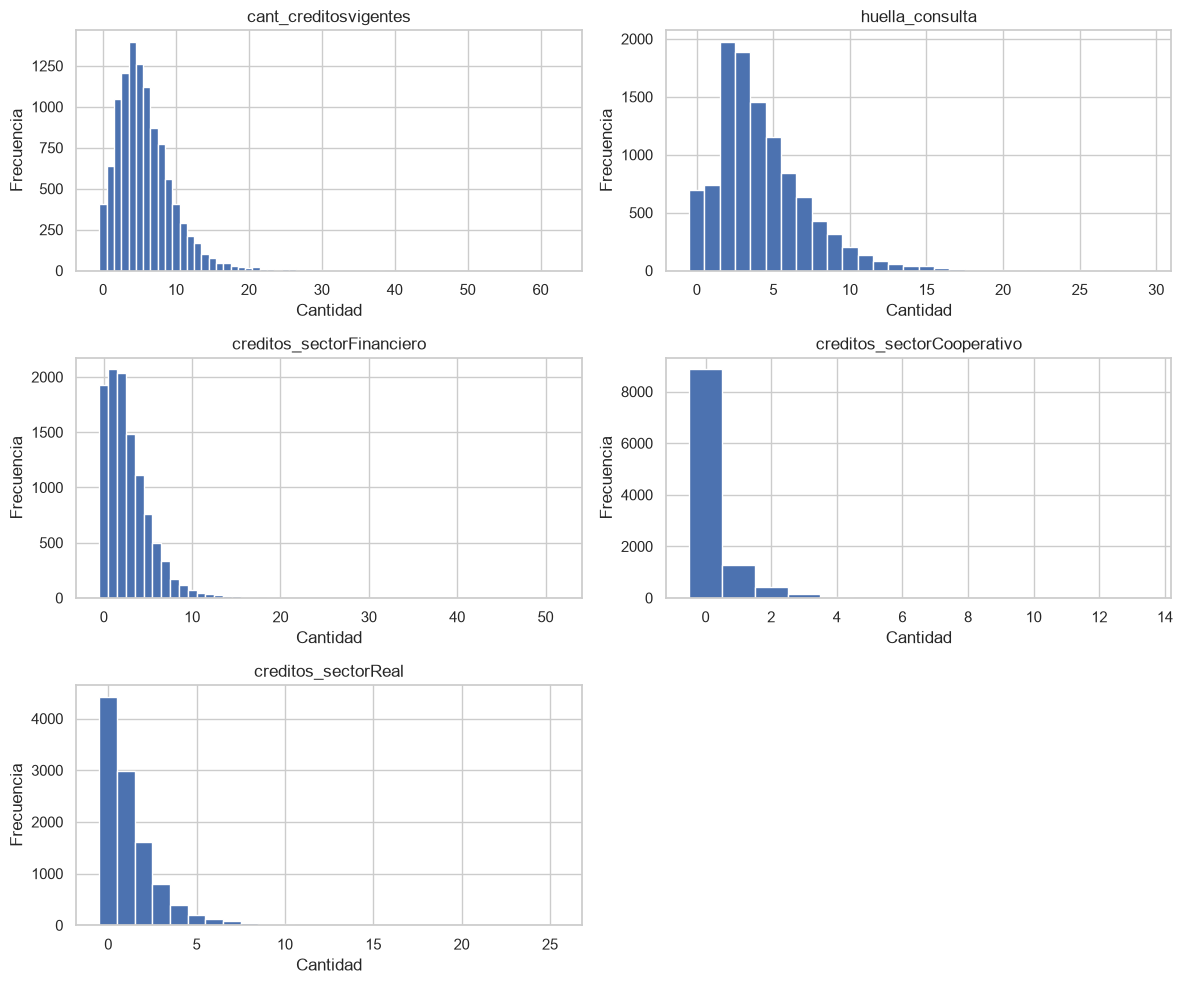

Registros en cero:
  cant_creditosvigentes             405 (  3.8%)
  huella_consulta                   700 (  6.5%)
  creditos_sectorFinanciero        1924 ( 17.9%)
  creditos_sectorCooperativo       8868 ( 82.4%)
  creditos_sectorReal              4426 ( 41.1%)


In [40]:
# Define las variables de conteo que se analizarán.
conteos = [
    "cant_creditosvigentes",
    "huella_consulta",
    "creditos_sectorFinanciero",
    "creditos_sectorCooperativo",
    "creditos_sectorReal"
]

# Crea una cuadrícula de seis espacios para mostrar cinco histogramas.
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Genera un histograma para cada variable de conteo.
for i, col in enumerate(conteos):
    datos = df_limpio[col]

    # Usa un intervalo por cada valor entero para evitar agrupar categorías.
    axes[i].hist(
        datos,
        bins=range(0, int(datos.max()) + 2),
        color="#4c72b0",
        edgecolor="white",
        align="left"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Cantidad")
    axes[i].set_ylabel("Frecuencia")

# Oculta el sexto panel porque no corresponde a ninguna variable.
axes[5].axis("off")

# Ajusta el diseño y muestra los histogramas.
plt.tight_layout()
plt.show()

# Calcula la cantidad y el porcentaje de clientes con valor cero.
print("Registros en cero:")
for col in conteos:
    ceros = (df_limpio[col] == 0).sum()
    porcentaje_ceros = ceros / len(df_limpio) * 100

    print(
        f"  {col:30} "
        f"{ceros:6} "
        f"({porcentaje_ceros:5.1f}%)"
    )

### Observaciones

`cant_creditosvigentes` y `huella_consulta` son las más regulares del dataset:
pico en 4-5 y 2-3, con descenso gradual. `creditos_sectorFinanciero` sigue el
mismo patrón con pico en 1-2.

**`creditos_sectorCooperativo` es casi constante**: el 82% de los clientes está
en cero, así que distingue muy poco. No la eliminamos porque, a diferencia de
las que sacamos por fuga, es información del historial previo y sí está
disponible al momento de la solicitud. Queda para evaluar en el bivariable.

`creditos_sectorReal` también concentra en cero pero se distribuye más.

### Distribución de scores y variables demográficas

Tres variables de naturaleza distinta a las anteriores: la edad del cliente, el
score externo de Datacrédito y el plazo del crédito.

C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\2748554234.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\2748554234.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_48116\2748554234.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)


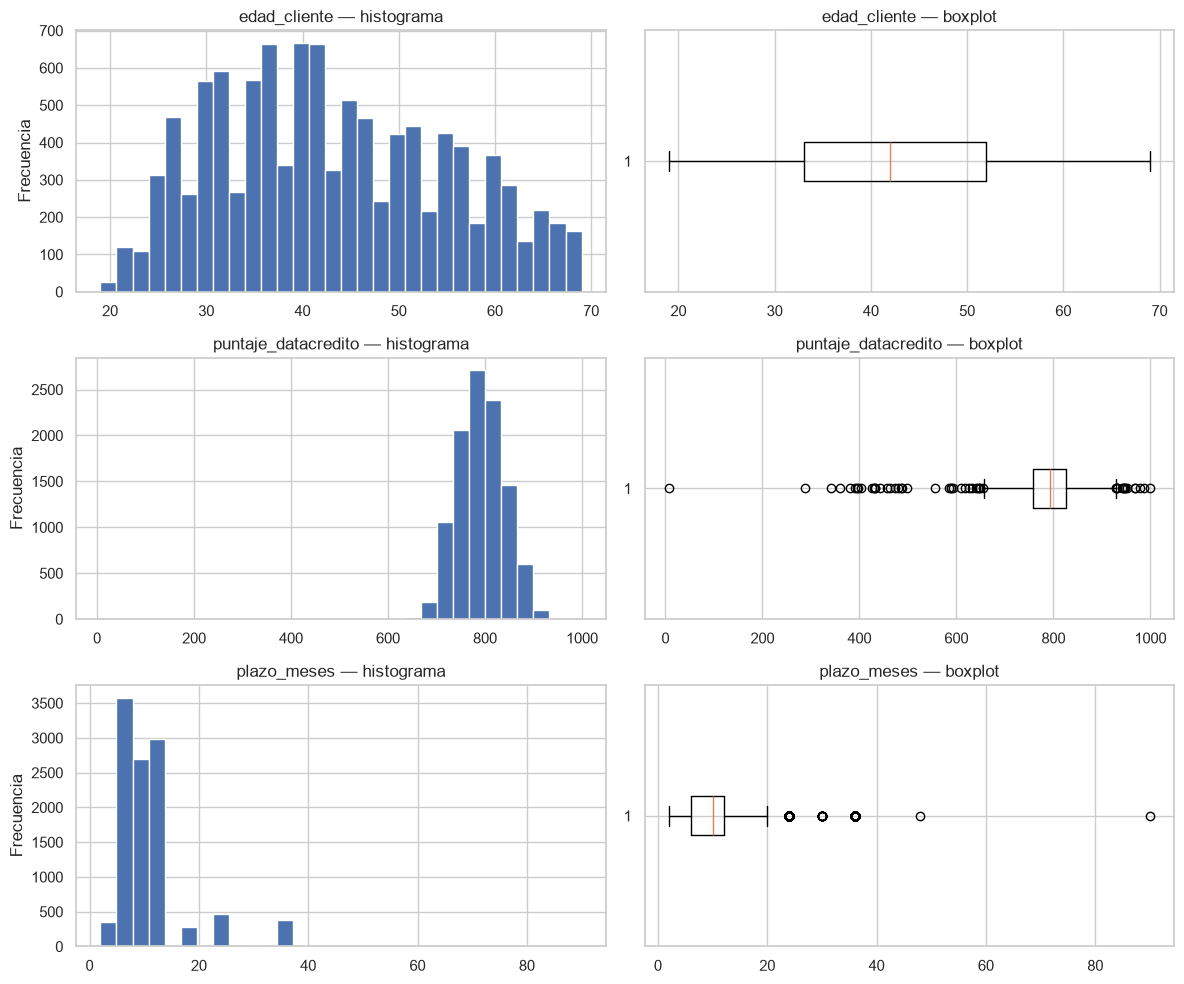

                       count    mean    std   min    25%    50%    75%    max
edad_cliente         10613.0   42.85  11.95  19.0   33.0   42.0   52.0   69.0
puntaje_datacredito  10611.0  791.53  51.43   7.0  758.0  792.0  826.0  999.0
plazo_meses          10763.0   10.58   6.63   2.0    6.0   10.0   12.0   90.0


In [41]:
# Define las variables demográficas y de características del crédito.
otras = [
    "edad_cliente",
    "puntaje_datacredito",
    "plazo_meses"
]

# Crea dos gráficos por variable: histograma y boxplot.
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Genera los gráficos y las estadísticas de cada variable.
for i, col in enumerate(otras):
    # Excluye los valores faltantes antes de graficar.
    datos = df_limpio[col].dropna()

    # Muestra la distribución de frecuencias mediante un histograma.
    axes[i, 0].hist(
        datos,
        bins=30,
        color="#4c72b0",
        edgecolor="white"
    )
    axes[i, 0].set_title(f"{col} — histograma")
    axes[i, 0].set_ylabel("Frecuencia")

    # Muestra la mediana, los cuartiles y los posibles valores extremos.
    axes[i, 1].boxplot(datos, vert=False)
    axes[i, 1].set_title(f"{col} — boxplot")

# Ajusta el diseño y muestra los gráficos.
plt.tight_layout()
plt.show()

# Genera estadísticas descriptivas para comparar las variables.
print(
    df_limpio[otras]
    .describe()
    .T
    .round(2)
)

### Observaciones

**`edad_cliente` es la única aproximadamente simétrica** (skew 0,27), entre 19 y
69 años. La simetría no equivale a normalidad —comprobarla requeriría una
prueba específica— pero contrasta con el resto del dataset. Su boxplot no tiene ni un outlier, único caso del dataset — confirma
que la corrección de los 150 registros mayores de 90 funcionó.

**`puntaje_datacredito` concentra entre 700 y 900** y es la única con sesgo
negativo: sus atípicos están por debajo del rango habitual, no por encima.
Coherente con un score, donde la mayoría puntúa bien y una minoría muy mal.

**`plazo_meses` no es continua.** Hasta 12 meses aparecen todos los valores
enteros pero concentrados en los habituales —6 (3.326), 12 (2.658) y 10 (1.520)
reúnen el 70%—; por encima de 12 solo hay redondos: 18, 24 y 36, más casos
aislados de 20, 30, 48 y 90. Se comporta como ordinal con pocos niveles.

### Distribución de las variables categóricas

Tres variables: `tipo_laboral` (dos categorías), `tipo_credito` (códigos
numéricos) y `tendencia_ingresos` (con la categoría `valor_anomalo` que
agregamos en la limpieza).

Los nulos se incluyen en el conteo a propósito: `tendencia_ingresos` tiene un
27% de faltantes, y ocultarlos daría una idea falsa de cómo se reparte.

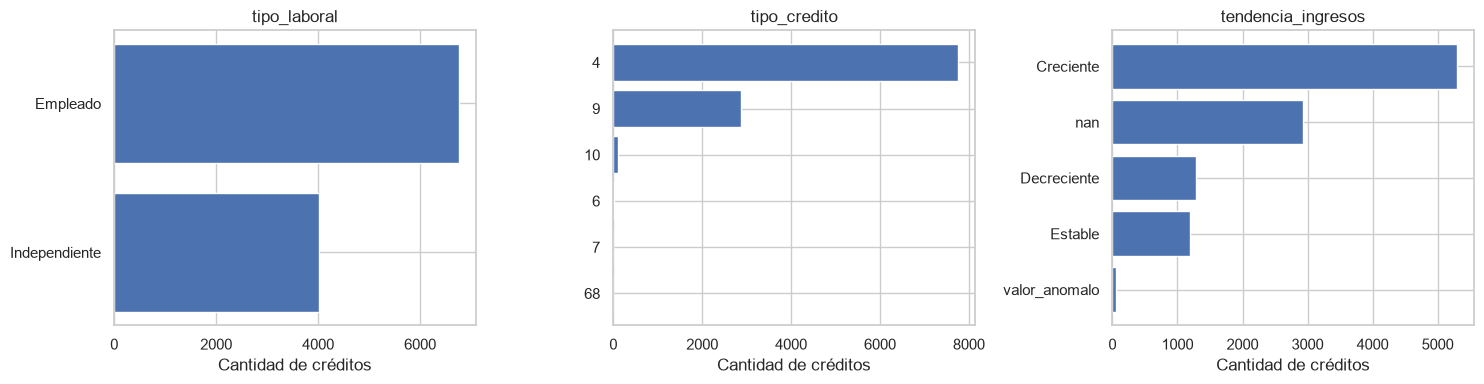


--- tipo_laboral ---
tipo_laboral
Empleado         62.75
Independiente    37.25
Name: proportion, dtype: float64

--- tipo_credito ---
tipo_credito
4     71.98
9     26.72
10     1.08
6      0.20
7      0.02
68     0.01
Name: proportion, dtype: float64

--- tendencia_ingresos ---
tendencia_ingresos
Creciente        49.19
NaN              27.24
Decreciente      11.99
Estable          11.04
valor_anomalo     0.54
Name: proportion, dtype: float64


In [42]:
# Define las variables categóricas que se analizarán.
categoricas = [
    "tipo_laboral",
    "tipo_credito",
    "tendencia_ingresos"
]

# Crea un gráfico para cada variable categórica.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Genera gráficos de barras horizontales con la frecuencia de cada categoría.
for i, col in enumerate(categoricas):
    # Incluye los valores nulos para representar toda la distribución.
    conteo = (
        df_limpio[col]
        .value_counts(dropna=False)
        .sort_values()
    )

    # Convierte las categorías a texto para utilizarlas como etiquetas.
    etiquetas = [str(x) for x in conteo.index]

    axes[i].barh(
        etiquetas,
        conteo.values,
        color="#4c72b0"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Cantidad de créditos")

# Ajusta el diseño y muestra los gráficos.
plt.tight_layout()
plt.show()

# Imprime el porcentaje que representa cada categoría.
for col in categoricas:
    print(f"\n--- {col} ---")

    porcentajes = (
        df_limpio[col]
        .value_counts(dropna=False, normalize=True)
        .round(4)
        * 100
    )

    print(porcentajes)

### Observaciones

**`tipo_laboral` es la mejor repartida:** Empleado 62,75%, Independiente 37,25%,
sin faltantes.

**`tipo_credito` está dominada por dos categorías:** el tipo 4 con 71,98% y el 9
con 26,72% suman el 98,7%. Los otros cuatro reúnen 140 registros. Categorías tan
chicas pueden quedar enteras de un lado al dividir los datos.

**En `tendencia_ingresos` los faltantes son la segunda categoría más
frecuente** (27,24%), por encima de Decreciente (11,99%) y Estable (11,04%) por
separado. Creciente encabeza con 49,19%.

Llama la atención que casi la mitad tenga tendencia Creciente —el 67% contando
solo los que tienen dato—. Podría reflejar la política de otorgamiento o algo
del armado del dataset; no hay forma de distinguirlo acá.

## Análisis bivariable

Se analiza la relación de cada variable con `Pago_atiempo`. La pregunta es cuál
de ellas distingue entre clientes que pagan y clientes que no.

Dado el desbalance (4,75% de impago), lo relevante no es cuántos impagos hay en
cada grupo sino **qué porcentaje** representa dentro de su grupo, y si ese
porcentaje se aparta de la tasa general.

### Variables categóricas

In [43]:
# Define las variables categóricas que se relacionarán con el impago.
categoricas_bi = [
    "tipo_laboral",
    "tipo_credito",
    "tendencia_ingresos"
]

# Calcula la tasa general de impago como referencia para comparar categorías.
tasa_general = (
    1 - df_limpio["Pago_atiempo"].mean()
) * 100

# Analiza el volumen y la tasa de impago dentro de cada categoría.
for col in categoricas_bi:
    tabla = (
        df_limpio
        .groupby(col, dropna=False)
        .agg(
            # Cantidad total de créditos dentro de cada categoría.
            creditos=("Pago_atiempo", "size"),

            # Cantidad de créditos que no se pagaron a tiempo.
            impagos=("Pago_atiempo", lambda x: (x == 0).sum()),

            # Porcentaje de impago dentro de cada categoría.
            pct_impago=(
                "Pago_atiempo",
                lambda x: (1 - x.mean()) * 100
            )
        )
        .round(2)
    )

    # Muestra la tabla ordenada desde la mayor hasta la menor tasa de impago.
    print(f"\n--- {col} (tasa general: {tasa_general:.2f}%) ---")
    print(
        tabla.sort_values(
            "pct_impago",
            ascending=False
        )
    )


--- tipo_laboral (tasa general: 4.75%) ---
               creditos  impagos  pct_impago
tipo_laboral                                
Independiente      4009      221        5.51
Empleado           6754      290        4.29

--- tipo_credito (tasa general: 4.75%) ---
              creditos  impagos  pct_impago
tipo_credito                               
6                   21        9       42.86
9                 2876      136        4.73
4                 7747      363        4.69
10                 116        3        2.59
7                    2        0        0.00
68                   1        0        0.00

--- tendencia_ingresos (tasa general: 4.75%) ---
                    creditos  impagos  pct_impago
tendencia_ingresos                               
Decreciente             1291       81        6.27
NaN                     2932      168        5.73
Estable                 1188       55        4.63
Creciente               5294      207        3.91
valor_anomalo             58  

In [44]:
from scipy.stats import binomtest

# Los valores se toman del dataset para que el resultado siga siendo válido
# si los datos cambian.
tipo6 = df_limpio[df_limpio["tipo_credito"] == 6]
n_casos = len(tipo6)
n_impagos = (tipo6["Pago_atiempo"] == 0).sum()
tasa_base = 1 - df_limpio["Pago_atiempo"].mean()

print(f"Tipo 6: {n_impagos} impagos en {n_casos} créditos "
      f"({n_impagos/n_casos*100:.2f}%)")
print(f"Tasa general: {tasa_base*100:.2f}%")
print(binomtest(n_impagos, n_casos, tasa_base, alternative="greater"))

Tipo 6: 9 impagos en 21 créditos (42.86%)
Tasa general: 4.75%
BinomTestResult(k=9, n=21, alternative='greater', statistic=0.42857142857142855, pvalue=2.1361735779094668e-07)


### Observaciones

**`tendencia_ingresos` ordena el riesgo de forma coherente:** Decreciente 6,27%,
sin dato 5,73%, Estable 4,63%, Creciente 3,91%. El orden coincide con lo
esperable —a ingresos en caída, mayor incumplimiento— y todos los grupos tienen
volumen suficiente. Los registros sin dato quedan segundos, lo que refuerza el
hallazgo previo sobre la asociación entre ausencia e impago.

La categoría `valor_anomalo` da 0%, pero con 58 casos —54 con `puntaje`
constante— el dato no es interpretable.

**`tipo_laboral`**: Independiente 5,51% contra Empleado 4,29%, un 28% más en
términos relativos y con respaldo de volumen.

**`tipo_credito` 6 concentra 42,86% de impago, nueve veces la tasa general.**
Son 21 créditos, pero la prueba binomial arroja un p-valor extremadamente bajo (p = 2,1 × 10⁻⁷): si
su tasa fuera la general, observar 9 impagos en 21 casos sería casi imposible.

El resultado establece que esos 21 registros se comportan distinto, no que la
tasa del tipo 6 sea 42,86% — con esa cantidad la estimación es imprecisa. Los
tipos 4 y 9, que son el 99% del dataset, están ambos en la tasa general y no
discriminan.

**Implicancia**: el tipo 6 es información relevante para el negocio, pero 21
casos son insuficientes para que un modelo aprenda el patrón de forma estable.

Los mismos datos en forma de gráfico. La línea punteada marca la tasa general
de impago (4,75%): lo relevante es qué categorías se apartan de ella y con qué
volumen.

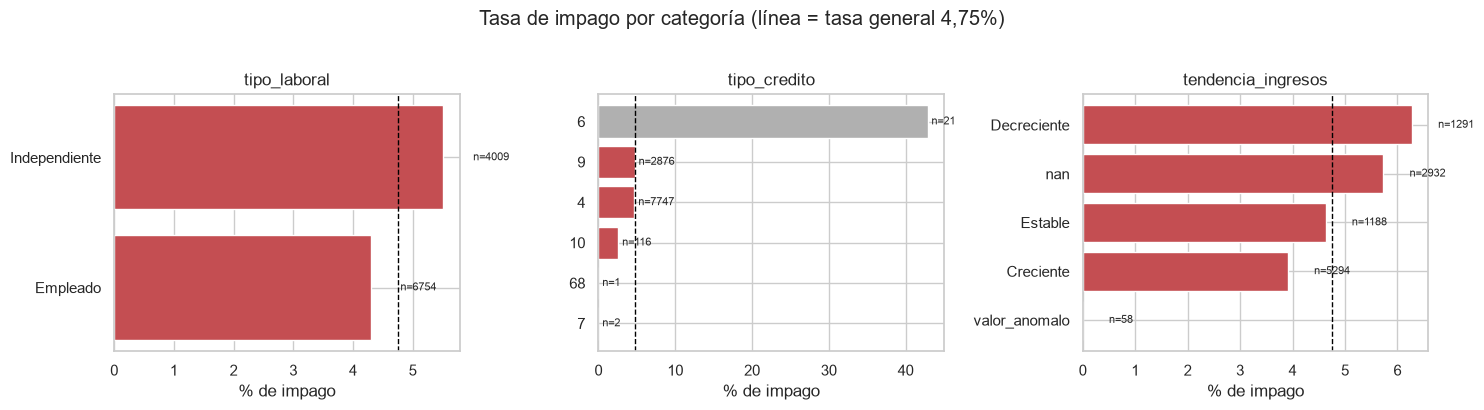

In [45]:
# Crea un gráfico para cada variable categórica analizada.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Calcula y representa la tasa de impago dentro de cada categoría.
for i, col in enumerate(categoricas_bi):
    tabla = (
        df_limpio
        .groupby(col, dropna=False)
        .agg(
            # Cuenta los créditos de cada categoría.
            creditos=("Pago_atiempo", "size"),

            # Calcula el porcentaje de créditos impagados.
            pct_impago=(
                "Pago_atiempo",
                lambda x: (1 - x.mean()) * 100
            )
        )
        .sort_values("pct_impago")
    )

    # Convierte las categorías a texto para mostrarlas en el eje Y.
    etiquetas = [str(x) for x in tabla.index]

    # Usa gris para grupos pequeños, cuya tasa es menos estable.
    colores = [
        "#c44e52" if n >= 100 else "#b0b0b0"
        for n in tabla["creditos"]
    ]

    # Dibuja la tasa de impago de cada categoría.
    axes[i].barh(
        etiquetas,
        tabla["pct_impago"],
        color=colores
    )

    # Añade una línea con la tasa general de impago.
    axes[i].axvline(
        tasa_general,
        color="black",
        linestyle="--",
        linewidth=1
    )

    # Etiqueta cada barra con la cantidad de créditos del grupo.
    for j, (pct, n) in enumerate(
        zip(tabla["pct_impago"], tabla["creditos"])
    ):
        axes[i].text(
            pct + 0.5,
            j,
            f"n={n}",
            va="center",
            fontsize=8
        )

    axes[i].set_title(col)
    axes[i].set_xlabel("% de impago")

# Añade un título general y muestra los gráficos.
plt.suptitle(
    "Tasa de impago por categoría "
    "(línea = tasa general 4,75%)",
    y=1.02
)
plt.tight_layout()
plt.show()

El gráfico usa color gris para los grupos con menos de 100 registros y muestra
el volumen al final de cada barra, de modo que las tasas se lean junto con la
evidencia que las sostiene.

### Variables numéricas

Para cada variable se comparan las medianas de ambos grupos. Se usa mediana y
no media porque casi todas las variables tienen sesgo fuerte, y el promedio
quedaría distorsionado por los valores extremos.

La columna `dif_%` expresa cuánto se aparta la mediana del grupo con impago
respecto de la del grupo que pagó.

In [46]:
# Calcula la mediana de cada variable numérica para cada clase de pago.
comparacion = (
    df_limpio
    .groupby("Pago_atiempo")[numericas]
    .median()
    .T
)

# Renombra las columnas para facilitar la comparación.
comparacion.columns = ["impago", "pago"]

# Calcula cuánto difiere la mediana del grupo de impago
# respecto a la mediana del grupo que pagó.
comparacion["dif_%"] = (
    (comparacion["impago"] / comparacion["pago"] - 1) * 100
).round(1)

# Ordena las variables desde la mayor diferencia positiva
# hasta la menor.
comparacion.sort_values(
    "dif_%",
    ascending=False
).round(1)

,impago,pago,dif_%
huella_consulta,5.0,4.0,25.0
capital_prestado,2268000.0,1908446.4,18.8
cuota_pactada,199002.0,182576.0,9.0
plazo_meses,10.0,10.0,0.0
cant_creditosvigentes,5.0,5.0,0.0
salario_cliente,3000000.0,3000000.0,0.0
creditos_sectorReal,1.0,1.0,0.0
creditos_sectorFinanciero,2.0,2.0,0.0
puntaje_datacredito,769.0,792.0,-2.9
saldo_principal,13110.0,14492.5,-9.5


In [47]:
# Importa la prueba no paramétrica de Mann-Whitney U.
from scipy.stats import mannwhitneyu

# Conserva únicamente las variables numéricas que todavía existen
# después de la limpieza del dataset.
numericas_bi = [
    c for c in numericas
    if c in df_limpio.columns
]

# Almacena los resultados de la prueba para cada variable.
resultados = []

# Compara cada variable entre los grupos de impago y pago.
for col in numericas_bi:
    # Selecciona los valores de los clientes que no pagaron a tiempo.
    g0 = (
        df_limpio
        .loc[df_limpio["Pago_atiempo"] == 0, col]
        .dropna()
    )

    # Selecciona los valores de los clientes que pagaron a tiempo.
    g1 = (
        df_limpio
        .loc[df_limpio["Pago_atiempo"] == 1, col]
        .dropna()
    )

    # Evalúa si las distribuciones de ambos grupos son diferentes.
    stat, p = mannwhitneyu(
        g0,
        g1,
        alternative="two-sided"
    )

    # Guarda el p-valor asociado a la variable.
    resultados.append({
        "variable": col,
        "p_valor": p
    })

# Ordena las variables por significancia estadística.
pd.DataFrame(resultados).sort_values(
    "p_valor"
).round(6)

,variable,p_valor
6,puntaje_datacredito,0.000000
8,huella_consulta,0.000000
2,edad_cliente,0.000000
14,promedio_ingresos_datacredito,0.000005
0,capital_prestado,0.000013
11,creditos_sectorFinanciero,0.001682
4,total_otros_prestamos,0.006763
12,creditos_sectorCooperativo,0.011075
13,creditos_sectorReal,0.058760
1,plazo_meses,0.099446


Los tests indican qué variables presentan diferencia real, pero no de qué
magnitud. Los boxplots muestran esa magnitud: cuánto se separan efectivamente
las distribuciones de cada grupo.

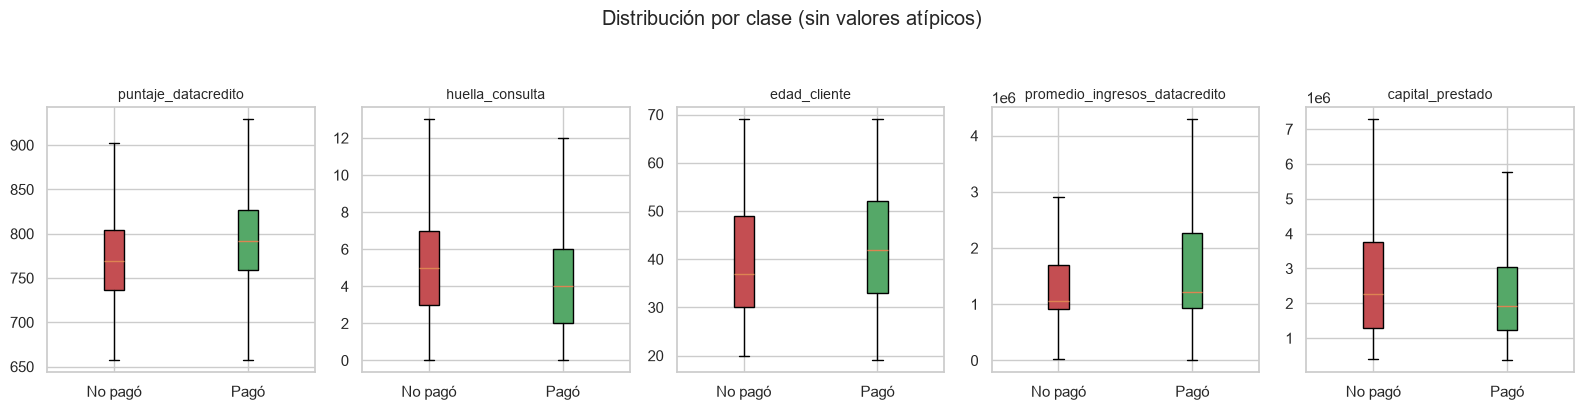

In [48]:
# Define las variables numéricas que muestran mayor diferencia entre las clases.
discriminan = [
    "puntaje_datacredito",
    "huella_consulta",
    "edad_cliente",
    "promedio_ingresos_datacredito",
    "capital_prestado"
]

# Crea un boxplot para cada variable seleccionada.
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

# Compara la distribución de cada variable entre impagos y pagos.
for i, col in enumerate(discriminan):
    # Separa los datos en dos grupos según el resultado del pago.
    datos = [
        df_limpio.loc[
            df_limpio["Pago_atiempo"] == 0,
            col
        ].dropna(),
        df_limpio.loc[
            df_limpio["Pago_atiempo"] == 1,
            col
        ].dropna()
    ]

    # Oculta los valores atípicos para facilitar la comparación del cuerpo
    # principal de cada distribución.
    bp = axes[i].boxplot(
        datos,
        tick_labels=["No pagó", "Pagó"],
        patch_artist=True,
        showfliers=False
    )

    # Asigna un color distinto a cada clase.
    bp["boxes"][0].set_facecolor("#c44e52")
    bp["boxes"][1].set_facecolor("#55a868")
    axes[i].set_title(col, fontsize=10)

# Añade un título general, ajusta el diseño y muestra los gráficos.
plt.suptitle(
    "Distribución por clase (sin valores atípicos)",
    y=1.02
)
plt.tight_layout()
plt.show()

### Observaciones

Cinco variables presentan diferencia estadísticamente significativa según Mann-Whitney:
`puntaje_datacredito`, `huella_consulta` y `edad_cliente` (p < 0,000001),
`promedio_ingresos_datacredito` (p = 0,000005) y `capital_prestado`
(p = 0,000013).

**Ninguna separa las clases.** Los boxplots muestran cajas superpuestas en los
cinco casos: las distribuciones están corridas una respecto de la otra, pero no
divididas. Un cliente con score 780 o con 5 consultas puede estar en cualquiera
de los dos grupos.

Las diferencias van en el sentido esperable. `huella_consulta` es la más
visible: mediana de 5 consultas en los impagos contra 4, con todo el rango
corrido hacia arriba — más consultas implican que el cliente está pidiendo
crédito en varias entidades a la vez. `puntaje_datacredito` y
`promedio_ingresos_datacredito` son menores en los impagos, `edad_cliente`
también (37 contra 42 años), y `capital_prestado` mayor (2,27 contra 1,91
millones).

**En `salario_cliente` no se detectó evidencia de diferencia** (p = 0,65), mientras que el
ingreso reportado por Datacrédito sí. La diferencia entre un dato autodeclarado
y uno verificado por un tercero se refleja en su capacidad predictiva.

**Implicancia**: la superposición es lo esperable tras eliminar las variables
con fuga. Ninguna variable individual permite clasificar; el modelo deberá
apoyarse en la combinación de varias.

**Limitación**: se aplicaron quince pruebas sobre el mismo conjunto de datos,
lo que aumenta la probabilidad de que alguna resulte significativa por azar.
Con corrección de Bonferroni el umbral pasaría de 0,05 a 0,0033: las cinco
variables mencionadas lo superan holgadamente, mientras que
`creditos_sectorFinanciero` (0,0017) queda al límite y
`creditos_sectorCooperativo` (0,011) dejaría de ser significativa. Los p-valores
tampoco informan la magnitud del efecto, que es lo que muestran los boxplots.

## Análisis multivariable

Se analizan las relaciones entre variables para detectar redundancias. Cuando
dos están muy correlacionadas el modelo no puede distinguir cuál explica el
resultado y sus coeficientes se vuelven inestables — es la multicolinealidad.

Se usan dos métodos. **Pearson** mide relaciones lineales con los valores
directos, y es sensible a los extremos. **Spearman** trabaja sobre el orden de
los valores en lugar de los valores mismos, lo que lo hace más robusto frente a
valores atípicos, aunque no inmune: los extremos siguen ocupando posiciones en
el ranking. Las diferencias entre ambas matrices indican dónde los atípicos
están distorsionando la medición.

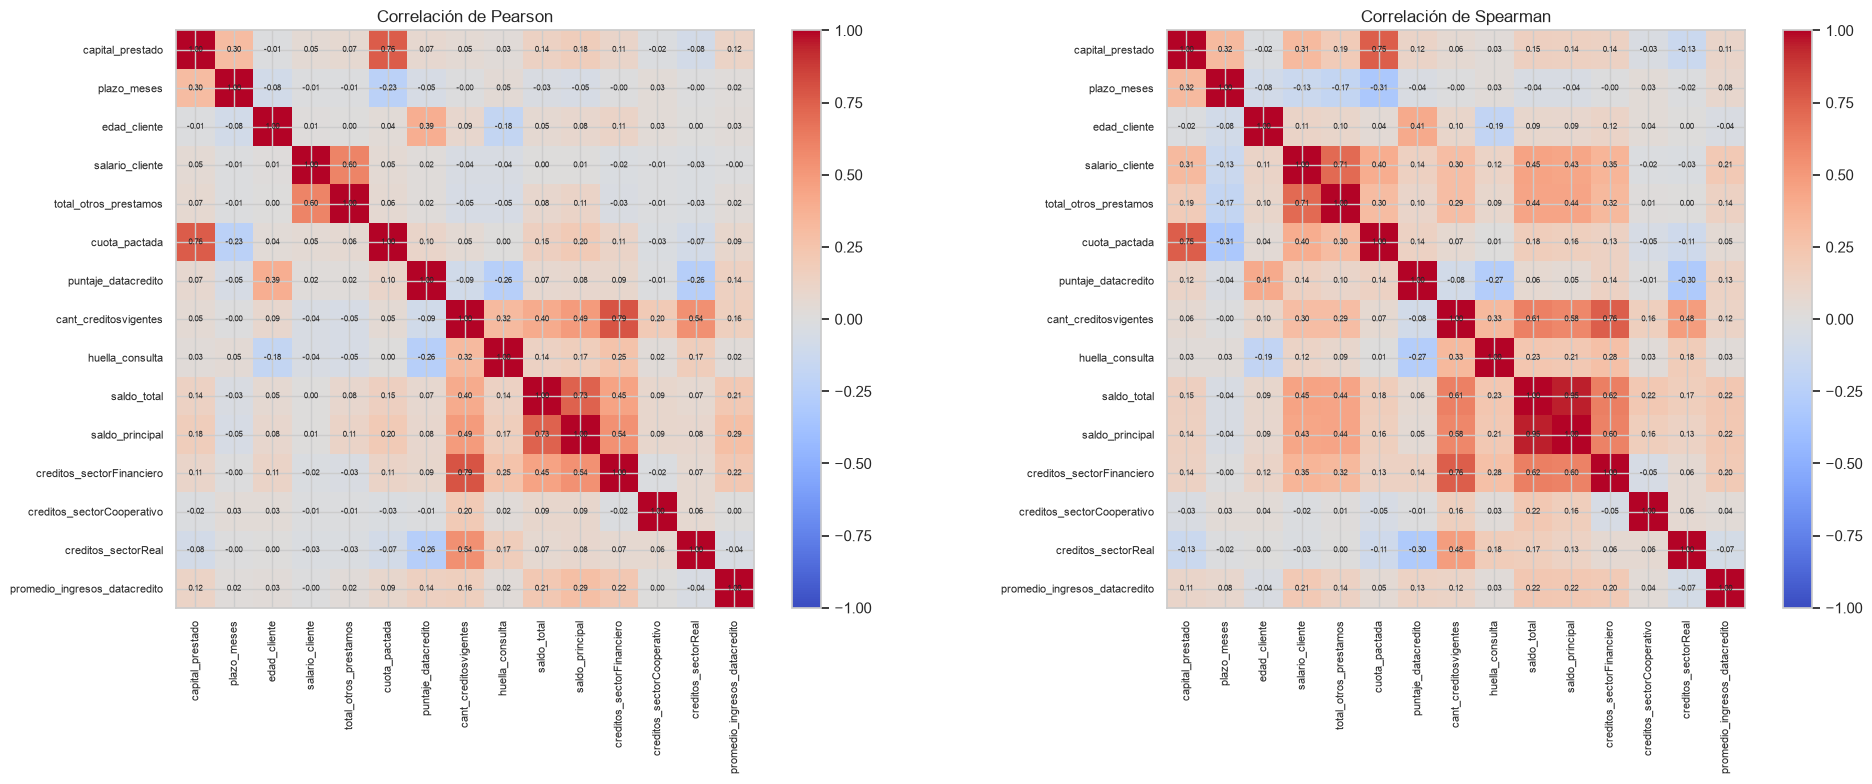

In [49]:
# Crea dos paneles para comparar las correlaciones de Pearson y Spearman.
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Genera una matriz de correlación con cada método.
for i, metodo in enumerate(["pearson", "spearman"]):
    corr = df_limpio[numericas_bi].corr(method=metodo)

    # Representa las correlaciones con un mapa de colores entre -1 y 1.
    im = axes[i].imshow(
        corr,
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    # Configura los nombres de las variables en ambos ejes.
    axes[i].set_xticks(range(len(numericas_bi)))
    axes[i].set_xticklabels(
        numericas_bi,
        rotation=90,
        fontsize=8
    )
    axes[i].set_yticks(range(len(numericas_bi)))
    axes[i].set_yticklabels(
        numericas_bi,
        fontsize=8
    )
    axes[i].set_title(
        f"Correlación de {metodo.capitalize()}"
    )

    # Escribe el valor numérico dentro de cada celda de la matriz.
    for x in range(len(numericas_bi)):
        for y in range(len(numericas_bi)):
            axes[i].text(
                y,
                x,
                f"{corr.iloc[x, y]:.2f}",
                ha="center",
                va="center",
                fontsize=6
            )

    # Añade una barra de color para interpretar la intensidad
    # y el sentido de cada correlación.
    fig.colorbar(
        im,
        ax=axes[i],
        fraction=0.046
    )

# Ajusta el diseño y muestra ambas matrices.
plt.tight_layout()
plt.show()

### Observaciones

**Tres pares con correlación alta:**

- `capital_prestado` — `cuota_pactada` (0,76 / 0,75): asociación positiva, en
  el sentido esperable.
- `cant_creditosvigentes` — `creditos_sectorFinanciero` (0,79 / 0,76): el total
  incluye los del sector financiero, que es el más frecuente.
- `saldo_total` — `saldo_principal` (0,73 / **0,90**): Spearman es
  sustancialmente mayor. Los extremos atenuaban la medición de Pearson; en
  términos de orden, ambas se comportan casi igual.

**`salario_cliente` es donde más difieren los dos métodos.** En Pearson no
correlaciona con nada (entre -0,02 y 0,06); en Spearman aparecen relaciones
consistentes: 0,45 con `saldo_total`, 0,40 con `cuota_pactada`, 0,35 con
`creditos_sectorFinanciero` y 0,31 con `capital_prestado`.

Es el efecto de su skew de 43,7: los valores extremos distorsionan la medición
lineal hasta hacerla poco informativa.
Las relaciones existen y son coherentes con el negocio —quien declara más
ingresos accede a créditos más grandes y acumula más deuda— pero solo se
detectan trabajando sobre rangos.

**Correlaciones negativas de interés:** `puntaje_datacredito` con
`huella_consulta` (-0,26 / -0,27) y con `creditos_sectorReal` (-0,26 / -0,30).
En cambio correlaciona positivo con `edad_cliente` (0,39 / 0,41), coherente con
un historial crediticio más extenso.

**Implicancia**: la redundancia entre los dos saldos debe evaluarse en la
preparación, y la discrepancia entre métodos confirma la necesidad de
transformar las variables de monto.

## Conclusiones

Decisiones para la etapa de preparación. La justificación de cada punto está en
su sección correspondiente.

### Reglas de validación

Definen los controles a aplicar sobre datos nuevos en producción. El
tratamiento propuesto es marcar el valor como faltante, no descartar el
registro: el resto de sus variables sigue siendo válido. Algunas reglas exceden
lo corregido en este notebook, donde solo se trataron los casos efectivamente
presentes en el dataset.

| Variable | Regla | Origen | Aplicada acá |
|---|---|---|---|
| `salario_cliente` | marcar como faltante si es ≤ 100.000 | 24 en 0, 7 por debajo del umbral | sí |
| `edad_cliente` | marcar como faltante fuera de 18–90 | 150 sobre 90, máximo de 123 | solo el techo: el mínimo observado es 19 |
| `puntaje_datacredito` | marcar como faltante fuera de 150–950 | 145 en 0, uno en -7 | solo ceros y negativos; quedan valores bajo 150 |
| `tendencia_ingresos` | Creciente, Estable o Decreciente | 58 registros con números | los anómalos quedan en `valor_anomalo`, categoría transitoria a resolver en la preparación |
| `tipo_credito` | códigos válidos conocidos | el 68 aparece una vez | no: se conserva y se resuelve al agrupar minoritarias |
| `plazo_meses` | entre 1 y 36 | 48 y 90 con un registro cada uno | no |
| montos | sin negativos | — | no requerido |

**Regla general**: el 0 no debe usarse como representación de dato faltante. Es
el patrón que se repite en `salario_cliente` y `puntaje_datacredito`.

### Transformaciones

Ninguna se aplica en este notebook: la consigna del avance pide identificarlas.
Se implementan en `ft_engineering.py`.

- **Logaritmo** en las variables de monto (skew de 3,72 → 0,11 en
  `capital_prestado`).
- **Imputación con indicador de ausencia**: los registros sin datos de
  Datacrédito tienen 5,73% de impago contra 4,38% (p = 0,0038), así que la
  ausencia es información.
- **Agrupar las categorías minoritarias** de `tipo_credito` —incluido el 68—,
  considerando que el tipo 6 tiene una tasa de impago muy superior.
- **Resolver `valor_anomalo`** en `tendencia_ingresos`: recodificar, convertir a
  nulo o mantener la categoría.
- **Tratar los valores extremos** de `salario_cliente` y
  `total_otros_prestamos`: el logaritmo solo no los integra.
- **Evaluar la redundancia** entre `saldo_total` y `saldo_principal`
  (Spearman 0,90).

### Atributos derivados

- **Indicadores de ausencia**: `sin_datos_datacredito` —cubre las dos variables
  que faltan juntas—, `sin_otros_prestamos`, `sin_saldo`.
- **Ratios de capacidad de pago**: cuota/salario, capital/salario y
  otros_prestamos/salario.
- **Diferencia entre saldos**: `saldo_total - saldo_principal` aísla el
  componente que no es capital.
- **Atributos temporales** desde `fecha_prestamo`: mes y trimestre.